# Reddit Data Analysis


## 1. Data Cleaning

### Data Downloading

Data collected on February 26th 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
birdflu = pd.read_csv('df_birdflu.csv')

In [3]:
birdflu.shape

(823, 10)

In [4]:
birdflupreps = pd.read_csv('df_birdflupreps.csv')

In [5]:
birdflupreps.shape

(1836, 10)

In [6]:
h5n1 = pd.read_csv('df_h5n1.csv')

In [7]:
h5n1.shape

(46696, 10)

In [8]:
combined = pd.concat([birdflu, birdflupreps, h5n1], ignore_index=True)

In [9]:
combined.shape

(49355, 10)

Adding the new_dates

In [10]:
new_dates=pd.read_csv('new_dates.csv')

In [11]:
new_dates.shape

(458, 10)

###Checking for duplicates

In [12]:
combined.duplicated().sum()

np.int64(0)

In [13]:
new_dates.duplicated().sum()

np.int64(0)

None of the dataframes contain duplicated values.

### Checking for Missing Values

In [14]:
combined.isnull().sum()

,0
subreddit,0
post_id,0
post_title,0
post_text,27155
post_score,0
post_created_utc,0
comment_id,0
comment_body,1
comment_score,0
comment_created_utc,0


In [15]:
combined['comment_body']=combined['comment_body'].dropna()

The only missing values are in the post_text column, which is fine. This is only a formatting issue, where people created posts only with a Title and no description to it in text_posts. Our main column for analysis is comment_body which presents no missing values.

### Checking for Deleted Posts

In [17]:
combined_deleted_comments = combined['comment_body'].str.lower().isin(['[deleted]', '[removed]']).sum()
print(f"Number of deleted/removed comments: {combined_deleted_comments}")

Number of deleted/removed comments: 2723


In [18]:
newdates_deleted_comments = new_dates['comment_body'].str.lower().isin(['[deleted]', '[removed]']).sum()
print(f"Number of deleted/removed comments: {newdates_deleted_comments}")

Number of deleted/removed comments: 0


Next, we will remove the removed comments.

In [19]:
combined = combined[~combined['comment_body'].str.lower().isin(['[deleted]', '[removed]'])]
combined_deleted_comments = combined['comment_body'].str.lower().isin(['[deleted]', '[removed]']).sum()
print(f"Number of deleted/removed comments: {combined_deleted_comments}")

Number of deleted/removed comments: 0


### Checking for Data Types

In [20]:
combined.dtypes

,0
subreddit,object
post_id,object
post_title,object
post_text,object
post_score,int64
post_created_utc,float64
comment_id,object
comment_body,object
comment_score,int64
comment_created_utc,float64


All data types work well for analysis, the only columns that need editing are the date columns (post_created_utc and comment_created_utc) that need to be converted to datetime.

In [21]:
combined['post_created_utc'] = pd.to_datetime(combined['post_created_utc'], unit='s')
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], unit='s')
combined.dtypes

,0
subreddit,object
post_id,object
post_title,object
post_text,object
post_score,int64
post_created_utc,datetime64[ns]
comment_id,object
comment_body,object
comment_score,int64
comment_created_utc,datetime64[ns]


All dataframes' date columns were succesfully changed to datetime type.

In [22]:
new_dates.dtypes

,0
subreddit,object
post_id,object
post_title,object
post_text,object
post_score,int64
post_created_utc,object
comment_id,object
comment_body,object
comment_score,int64
comment_created_utc,object


In [24]:
new_dates['post_created_utc'] = pd.to_datetime(new_dates['post_created_utc'])
new_dates['comment_created_utc'] = pd.to_datetime(new_dates['comment_created_utc'])
new_dates.dtypes

,0
subreddit,object
post_id,object
post_title,object
post_text,object
post_score,int64
post_created_utc,datetime64[ns]
comment_id,object
comment_body,object
comment_score,int64
comment_created_utc,datetime64[ns]


### Merging Combined + New Dates

In [25]:
combined = pd.concat([combined, new_dates], ignore_index=True)
combined.dtypes

,0
subreddit,object
post_id,object
post_title,object
post_text,object
post_score,int64
post_created_utc,datetime64[ns]
comment_id,object
comment_body,object
comment_score,int64
comment_created_utc,datetime64[ns]


##Individual Analysis

### Amount of Posts

In [26]:
combined['post_id'].nunique()


1456

### Amount of Comments

In [27]:
combined['comment_id'].nunique()

47090

### Average Posts Score

In [28]:
combined['post_score'].mean()

np.float64(485.978827776598)

The average post score shows how active or popular each subreddit is. Higher scores mean more people saw the posts and clicked to vote on them. The H5N1_AvianFlu subreddit has much higher average, which suggests they get more attention and interaction than BirdFlu or BirdFluPreps. The combined dataframe reflects all dataframes correctly.

### Average Comments Score

In [29]:
combined['comment_score'].mean()

np.float64(15.443533658950946)

The average comments score follows the same trend as for the average post score.

### Scores Visualization

<Axes: title={'center': 'Total - Distribution of Post Scores'}, ylabel='Frequency'>

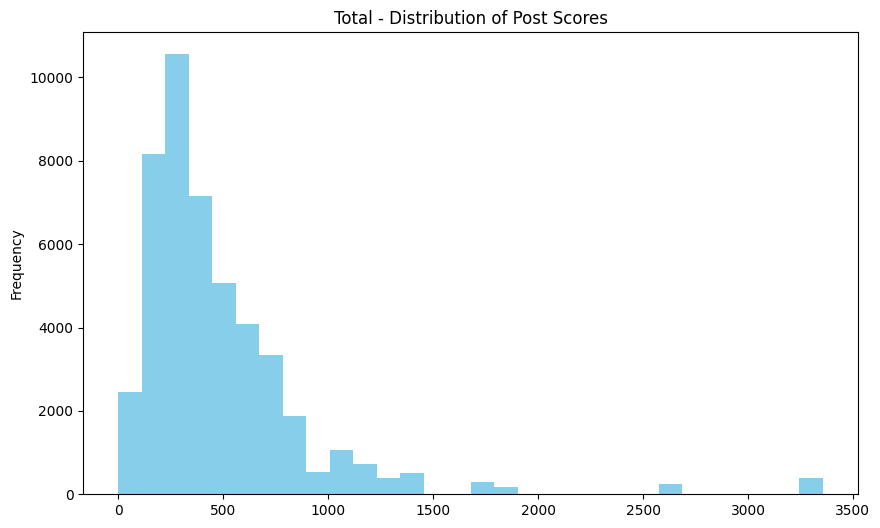

In [30]:
# Combined - Histogram of post scores
combined['post_score'].plot(kind='hist', bins=30, color='skyblue',
                           figsize=(10,6), title='Total - Distribution of Post Scores')

<Axes: title={'center': 'Total - Distribution of Comment Scores'}, ylabel='Frequency'>

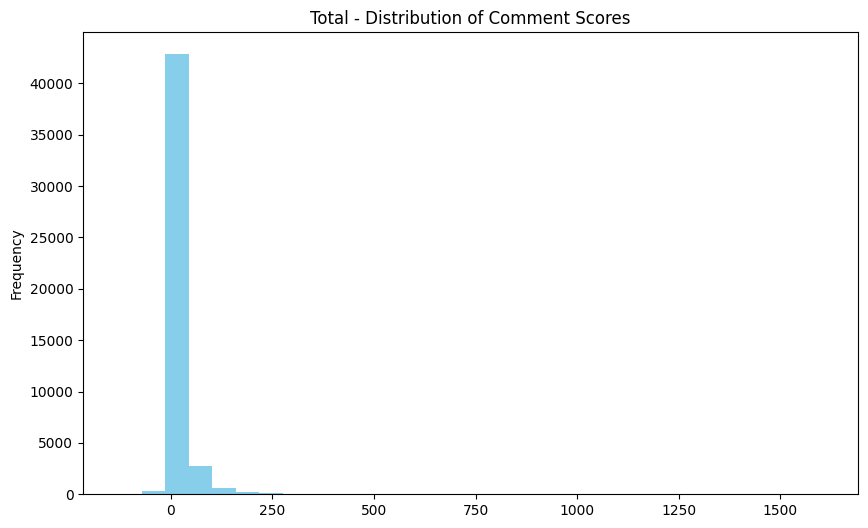

In [33]:
# Combined - Histogram of comment scores
combined['comment_score'].plot(kind='hist', bins=30, color='skyblue',
                           figsize=(10,6), title='Total - Distribution of Comment Scores')

<Axes: title={'center': 'Total - Distribution of Comments per Post'}>

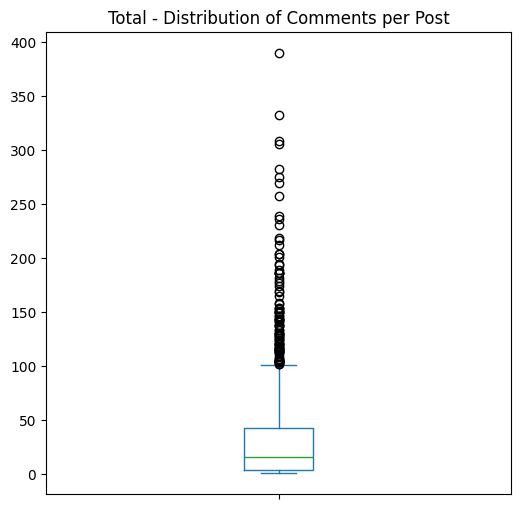

In [32]:
# Combined - Boxplot of comment counts per post
combined.groupby('post_id').size().plot(kind='box', figsize=(6,6),
                                       title='Total - Distribution of Comments per Post')

### Datetime Range

In [34]:
print("Post date range:", combined['post_created_utc'].min(), "to", combined['post_created_utc'].max())
print("Comment date range:", combined['comment_created_utc'].min(), "to", combined['comment_created_utc'].max())

Post date range: 2010-08-27 01:36:55 to 2025-12-29 22:35:07
Comment date range: 2010-08-27 02:46:12 to 2025-12-29 23:21:13


The combined dataframe contains posts and comments from Aug 27 2010 to Dec 29 2025 as expected.

###Datetime Visualiztion

####Posts

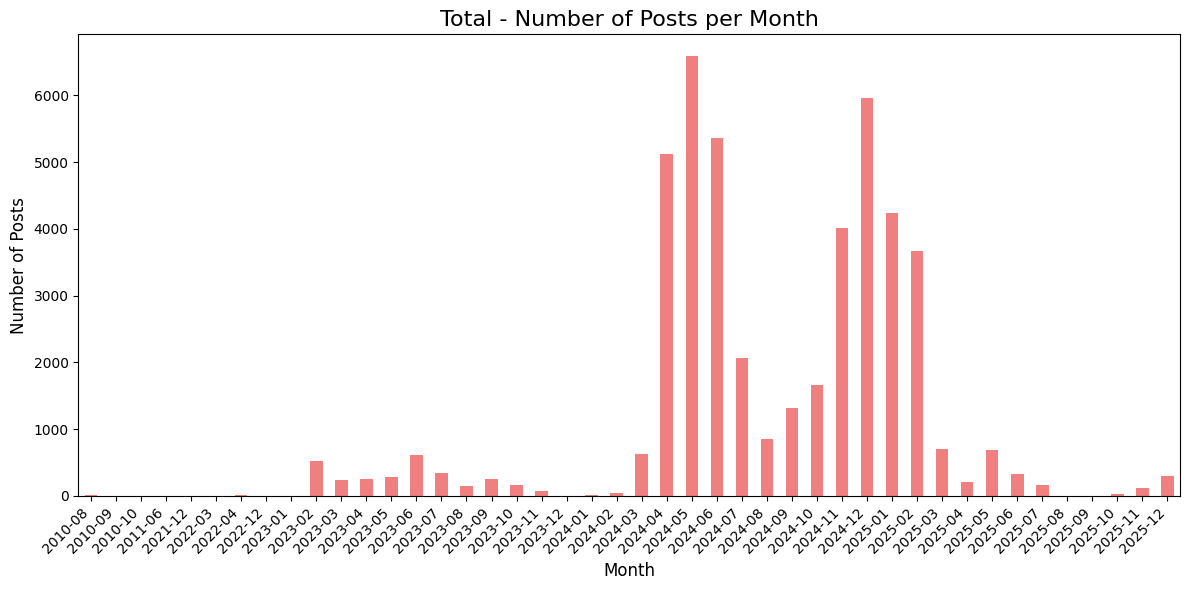

In [35]:
posts_per_month = combined.groupby(combined['post_created_utc'].dt.to_period('M')).size()

# Plot
plt.figure(figsize=(12, 6))
posts_per_month.plot(kind='bar', color='lightcoral')

plt.title('Total - Number of Posts per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
combined['post_created_utc'].dt.year.value_counts().sort_index()

,count
post_created_utc,
2010,23
2011,1
2021,1
2022,12
2023,2930
2024,33653
2025,10470


####Comments

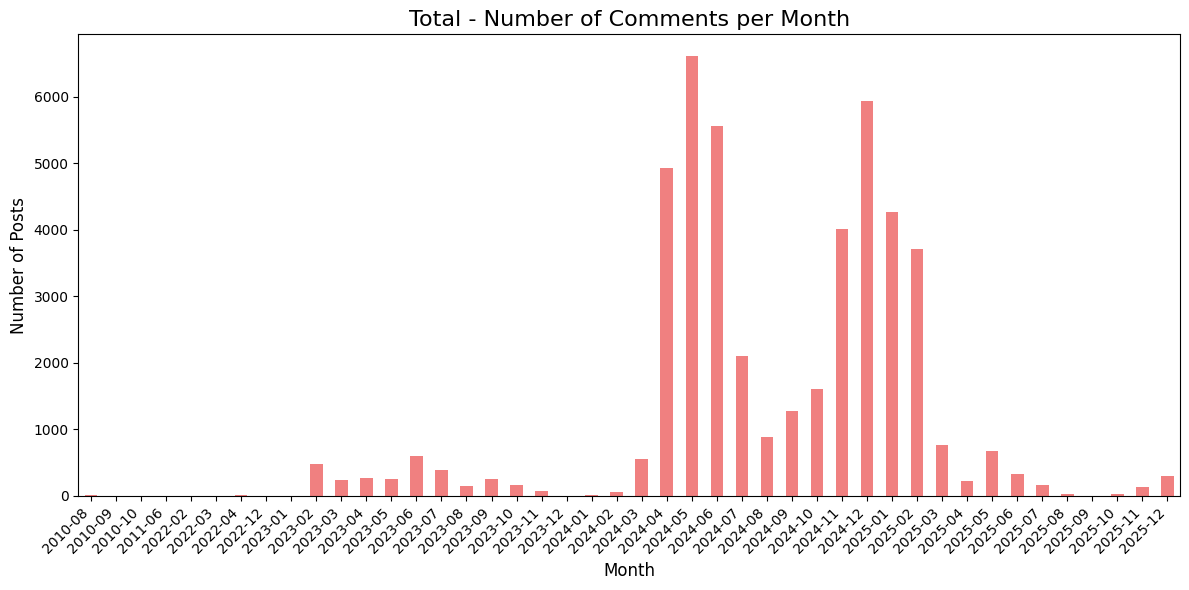

In [37]:
posts_per_month = combined.groupby(combined['comment_created_utc'].dt.to_period('M')).size()

# Plot
plt.figure(figsize=(12, 6))
posts_per_month.plot(kind='bar', color='lightcoral')

plt.title('Total - Number of Comments per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
combined['comment_created_utc'].dt.year.value_counts().sort_index()

,count
comment_created_utc,
2010,23
2011,1
2022,13
2023,2893
2024,33532
2025,10628


##Datetime Cleanup

In [39]:
combined.shape

(47090, 10)

In [40]:
# Remove data before 2022 due to small amount of comments
combined = combined[combined['comment_created_utc'] >= '2023-01-01'].reset_index(drop=True)

In [41]:
combined.shape

(47053, 10)

Data points from 2022 and before that were sucessfully romeved, now there is only data of 2023 and following years.

##Text Preprocessing

In [42]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import punkt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [43]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import string
import nltk
from text_prettifier import TextPrettifier
import re

In [44]:
# Cleaning Function
PUNCTUATION = set(string.punctuation) # defining functions
STOPWORDS = set(stopwords.words('english'))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()
PRETTIFIER = TextPrettifier()

def tokenize_X(text):
  text = str(text)
  text = PRETTIFIER.remove_emojis(str(text)) # remove emojis
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  tokens = word_tokenize(str(text)) # tokenizing words

  lowercased = [t.lower() for t in tokens] # making all content lowercased

  no_punctuation = []
  for word in lowercased:
    punct_removed = ''. join([letter for letter in word if not letter in PUNCTUATION])
    no_punctuation.append(punct_removed) # removing punctuation

  no_stopwords = [word for word in no_punctuation if not word in STOPWORDS] # removing stopwords

  no_numbers = [word for word in no_stopwords if not word.isdigit()] # removing numbers

  stemmed = [STEMMER.stem(word) for word in no_numbers] # removing suffixes from words
  lemmatized = [LEMMATIZER.lemmatize(word) for word in stemmed] # converting words to their base form

  return [word for word in lemmatized if word]

In [45]:
# Applying Cleaning Function to Combined
combined['post_title'] = combined['post_title'].apply(tokenize_X)
combined['clean_post_text'] = combined['post_text'].apply(tokenize_X) # applying cleaning function
combined['clean_comment_text'] = combined['comment_body'].apply(tokenize_X) # applying cleaning function

for i in range(3): # comparing original and cleaned comments
    print(f"Original: {combined['comment_body'].iloc[i]}")
    print(f"Cleaned tokens: {combined['clean_comment_text'].iloc[i]}")
    print("-" * 90)

Original: Ya man - I actually caught wind of covid Jan 10th 2020, just as it was gaining steam in wuhan, far before it went mainstream.

This is absolutely not getting covered because of fatigue.  If it was pre-covid, there would be some serious warnings about avoiding sick animals and a whole host of other things. 

Just saw a vid posted of a woman taking a sick duck to a vet. Bad news man.

Also, this risk is coming at a time where a significant portion of the planet has lowered immunity due to covid impact. The return cycle of a flu pandemic is still overdue, but it might be coming at the worst possible time.  Exactly when tons of people will refuse to respond.
Cleaned tokens: ['ya', 'man', 'actual', 'caught', 'wind', 'covid', 'jan', '10th', 'gain', 'steam', 'wuhan', 'far', 'went', 'mainstream', 'absolut', 'get', 'cover', 'fatigu', 'precovid', 'would', 'seriou', 'warn', 'avoid', 'sick', 'anim', 'whole', 'host', 'thing', 'saw', 'vid', 'post', 'woman', 'take', 'sick', 'duck', 'vet', '

In [46]:
combined.head()

,subreddit,post_id,post_title,post_text,post_score,post_created_utc,comment_id,comment_body,comment_score,comment_created_utc,clean_post_text,clean_comment_text
0,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j826b63,Ya man - I actually caught wind of covid Jan 1...,29,2023-02-11 01:52:53,"[give, seriou, deja, vu, vibe, around, time, y...","[ya, man, actual, caught, wind, covid, jan, 10..."
1,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82jlm0,"Yeah, I was, but I was also early to /r/monkey...",28,2023-02-11 03:43:02,"[give, seriou, deja, vu, vibe, around, time, y...","[yeah, also, earli, rmonkeypox, nt, explod, al..."
2,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j8296o5,This was exactly what I was thinking just now ...,15,2023-02-11 02:15:52,"[give, seriou, deja, vu, vibe, around, time, y...","[exactli, think, look, birdflu, sub]"
3,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82etwu,I was like the 75th person on ChinaFlu and am ...,12,2023-02-11 03:02:10,"[give, seriou, deja, vu, vibe, around, time, y...","[like, 75th, person, chinaflu, definit, get, v..."
4,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82pkts,Yep. First I heard of it was 31st of December ...,12,2023-02-11 04:37:23,"[give, seriou, deja, vu, vibe, around, time, y...","[yep, first, heard, 31st, decemb, radio, way, ..."


In [47]:
combined.shape

(47053, 12)

##NLP Content Analysis

###Text Lenght

In [48]:
combined['post_text'].str.split().str.len().mean()

np.float64(198.94288398309067)

In [49]:
combined['comment_body'].str.split().str.len().mean()

np.float64(42.926974411289635)

The combined dataframe has an average of 198 words per post text, and 43 words per comment text.

###Word Distribution

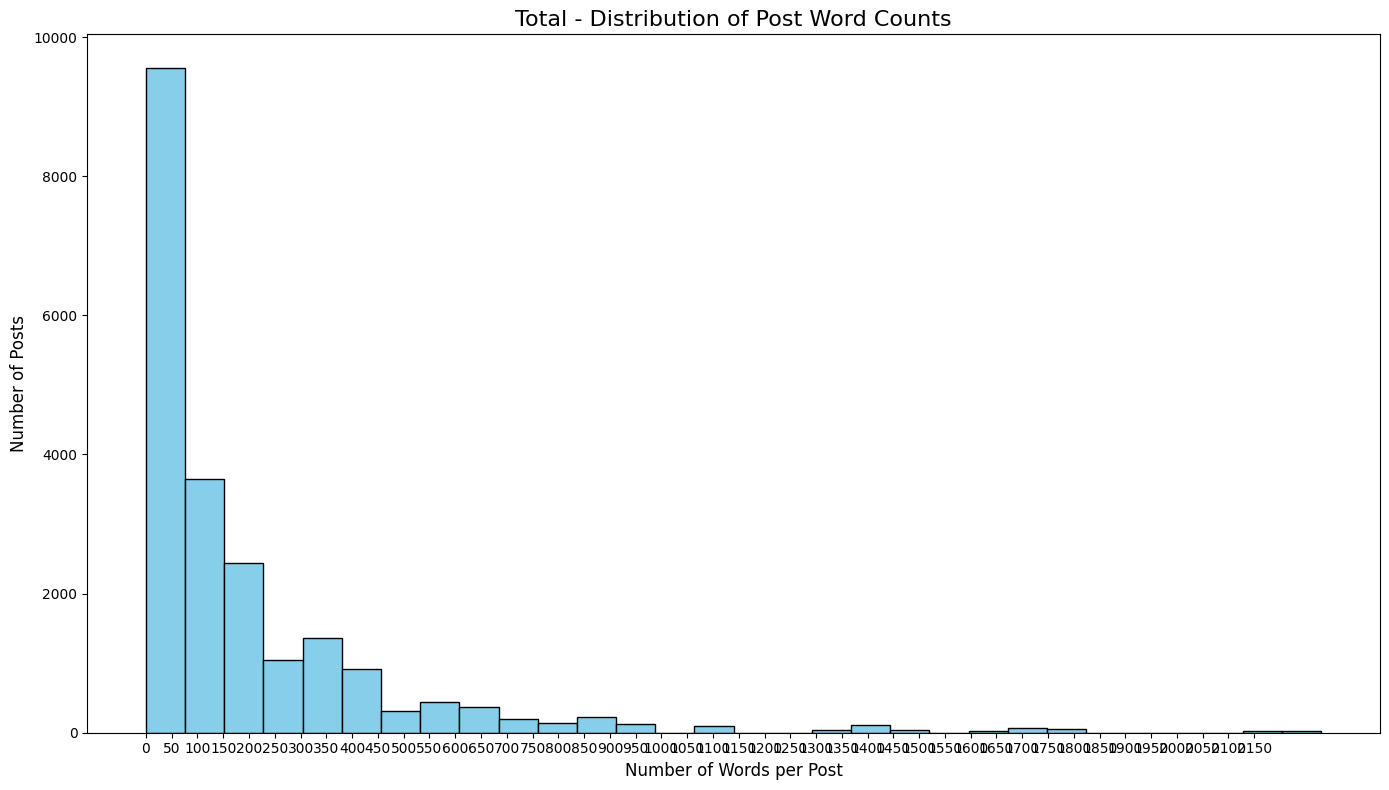

In [50]:
word_counts = combined['post_text'].str.split().str.len()

plt.figure(figsize=(14, 8))
plt.hist(word_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Total - Distribution of Post Word Counts', fontsize=16)
plt.xlabel('Number of Words per Post', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.xticks(np.arange(0, 2200, 50))
plt.tight_layout()
plt.show()

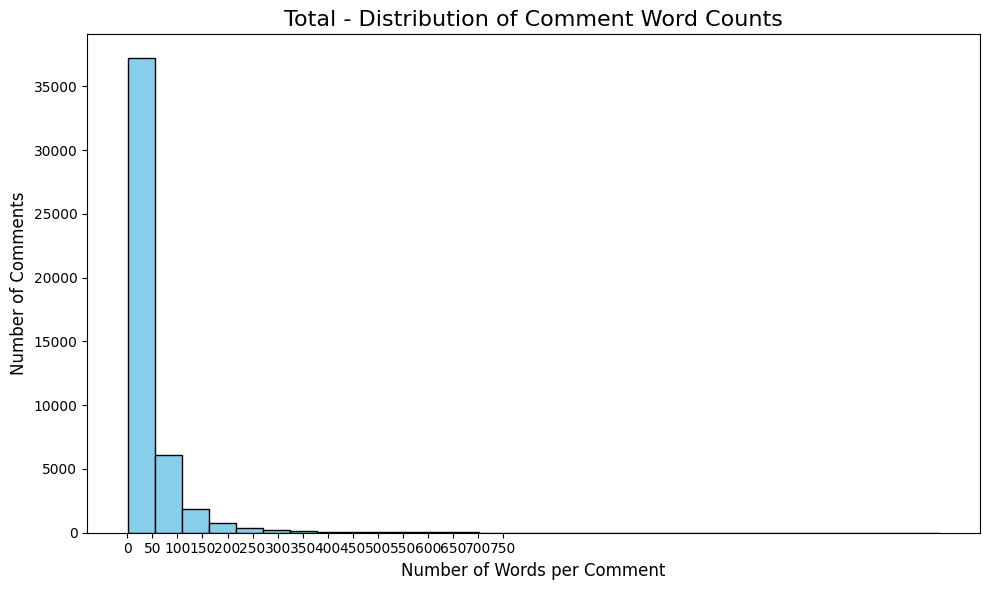

In [51]:
word_counts = combined['comment_body'].str.split().str.len()

plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Total - Distribution of Comment Word Counts', fontsize=16)
plt.xlabel('Number of Words per Comment', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(np.arange(0, 800, 50))
plt.tight_layout()
plt.show()

### Cleanup for Grams



In [52]:
MODERATOR_PATTERNS = [
    r"\bmoderator\b",
    r"\bmoderation\b",
    r"\bautomated\b",
    r"\bbot\b",
    r"\bthis action was performed automatically\b",
    r"\bplease contact the moderators\b",
    r"\bcontact the moderators\b",
    r"\bmessage the moderators\b",
    r"\bmoder\b",
    r"\bmessagecompos\b",
    r"\bautomat\b",
    r"\brefrain\b",
    r"\bcivil\b",
    r"\banonym\b",
    r"\bspam\b",
    r"\bclick\b",
    r"\bdelet\b"
]

def is_moderator_comment(text):
    for pattern in MODERATOR_PATTERNS:
        if re.search(pattern, text, re.IGNORECASE):
            return True
    return False

combined['is_moderator_comment'] = combined['clean_comment_text'].apply(
    lambda tokens: is_moderator_comment(" ".join(tokens)) if isinstance(tokens, list) else False
)

In [53]:
combined['is_moderator_comment'].value_counts()


,count
is_moderator_comment,
False,45759
True,1294


In [54]:
combined = combined[~combined['is_moderator_comment']].reset_index(drop=True)


In [55]:
combined.shape

(45759, 13)

In [56]:
combined.head()

,subreddit,post_id,post_title,post_text,post_score,post_created_utc,comment_id,comment_body,comment_score,comment_created_utc,clean_post_text,clean_comment_text,is_moderator_comment
0,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j826b63,Ya man - I actually caught wind of covid Jan 1...,29,2023-02-11 01:52:53,"[give, seriou, deja, vu, vibe, around, time, y...","[ya, man, actual, caught, wind, covid, jan, 10...",False
1,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82jlm0,"Yeah, I was, but I was also early to /r/monkey...",28,2023-02-11 03:43:02,"[give, seriou, deja, vu, vibe, around, time, y...","[yeah, also, earli, rmonkeypox, nt, explod, al...",False
2,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j8296o5,This was exactly what I was thinking just now ...,15,2023-02-11 02:15:52,"[give, seriou, deja, vu, vibe, around, time, y...","[exactli, think, look, birdflu, sub]",False
3,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82etwu,I was like the 75th person on ChinaFlu and am ...,12,2023-02-11 03:02:10,"[give, seriou, deja, vu, vibe, around, time, y...","[like, 75th, person, chinaflu, definit, get, v...",False
4,Birdflu,10z8r3z,"[mani, earli, chinaflu, subreddit, year, ago]",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82pkts,Yep. First I heard of it was 31st of December ...,12,2023-02-11 04:37:23,"[give, seriou, deja, vu, vibe, around, time, y...","[yep, first, heard, 31st, decemb, radio, way, ...",False


###Unigram Analysis

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd

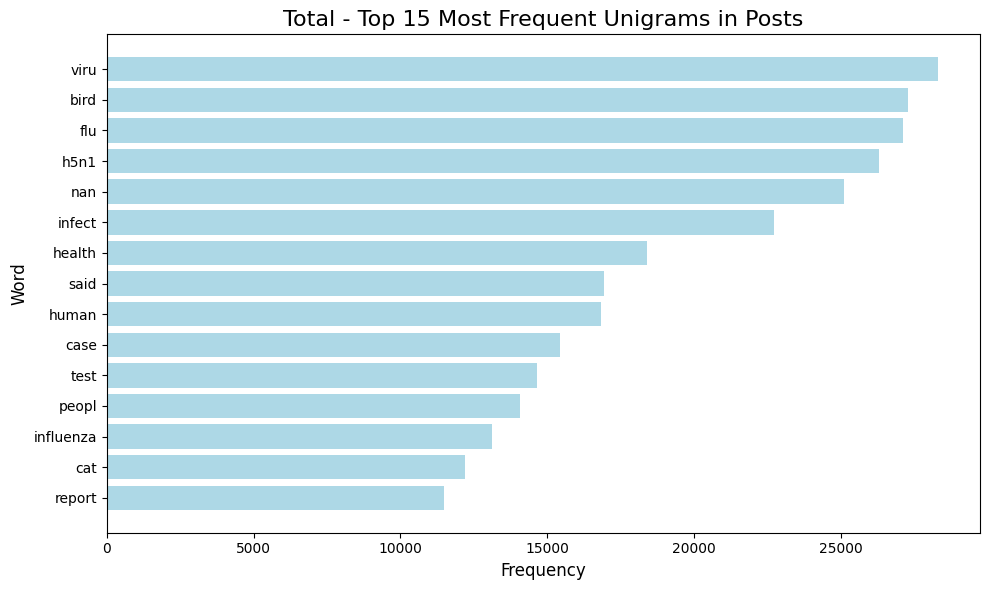

In [58]:
vectorizer = CountVectorizer(stop_words='english') # Create and fit CountVectorizer
X = vectorizer.fit_transform(combined['clean_post_text'].apply(lambda x: ' '.join(x)).dropna())


# Sum word frequencies
word_freq = X.sum(axis=0)
word_freq = [(word, word_freq[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

# Create DataFrame and get top 15
freq_df = pd.DataFrame(word_freq, columns=['word', 'count']).sort_values(by='count', ascending=False).head(15)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(freq_df['word'][::-1], freq_df['count'][::-1], color='lightblue')
plt.title('Total - Top 15 Most Frequent Unigrams in Posts', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

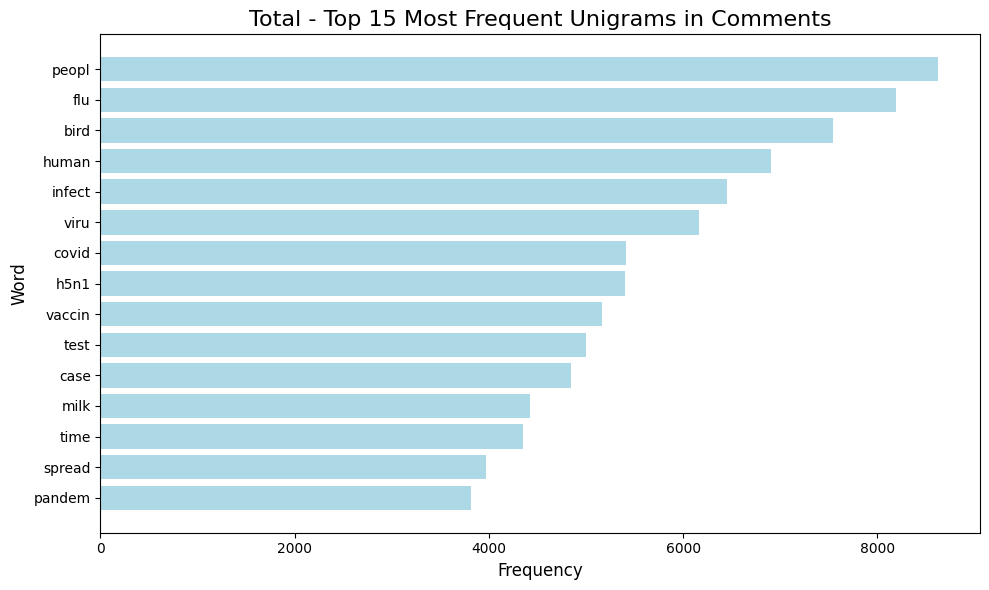

In [59]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd
X = vectorizer.fit_transform(combined['clean_comment_text'].apply(lambda x: ' '.join(x)).dropna())

# Sum word frequencies
word_freq = X.sum(axis=0)
word_freq = [(word, word_freq[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

# Create DataFrame and get top 15
freq_df = pd.DataFrame(word_freq, columns=['word', 'count']).sort_values(by='count', ascending=False).head(19)
freq_df = freq_df[freq_df['word'] != 'nt']
freq_df = freq_df[freq_df['word'] != 'like']
freq_df = freq_df[freq_df['word'] != 'know']
freq_df = freq_df[freq_df['word'] != 'think']
# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(freq_df['word'][::-1], freq_df['count'][::-1], color='lightblue')
plt.title('Total - Top 15 Most Frequent Unigrams in Comments', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.tight_layout()
plt.show()

### Bigram Analysis

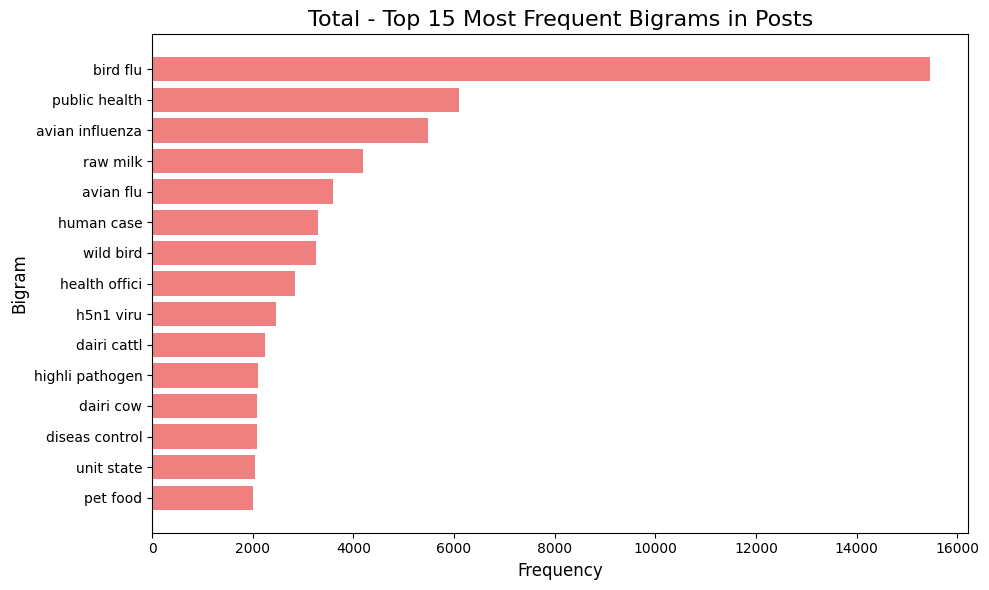

In [60]:
# Create and fit CountVectorizer for bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
X = vectorizer.fit_transform(combined['clean_post_text'].apply(lambda x: ' '.join(x)).dropna())

# Sum word frequencies
word_freq = X.sum(axis=0)
word_freq = [(word, word_freq[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

# Create DataFrame and get top 15 bigrams
freq_df = pd.DataFrame(word_freq, columns=['bigram', 'count']).sort_values(by='count', ascending=False).head(15)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(freq_df['bigram'][::-1], freq_df['count'][::-1], color='lightcoral')
plt.title('Total - Top 15 Most Frequent Bigrams in Posts', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Bigram', fontsize=12)
plt.tight_layout()
plt.show()

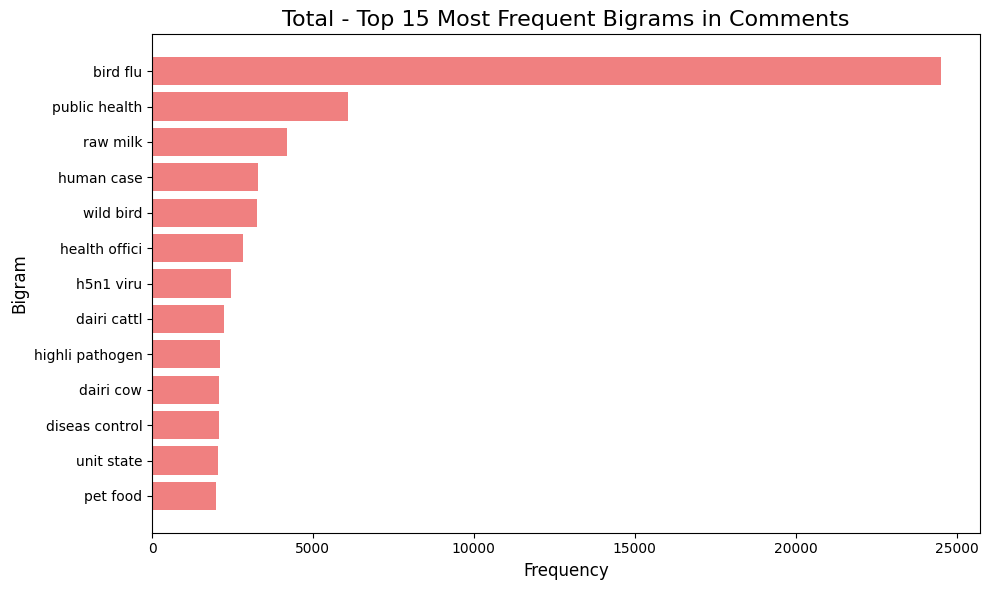

In [63]:
# Create and fit CountVectorizer for bigrams
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2))
X = vectorizer.fit_transform(combined['clean_comment_text'].apply(lambda x: ' '.join(x)).dropna())

# Sum word frequencies
word_freq = X.sum(axis=0)
word_freq = [(word, word_freq[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

merge_map = {
    'avian influenza': 'avian flu',
    'avian flu': 'avian flu',
    'influenza avian': 'avian flu',
    'avian flu': 'bird flu'
}

# Apply the merge map, then re-sum so merged bigrams combine their counts
freq_df['bigram'] = freq_df['bigram'].apply(lambda x: merge_map.get(x, x))
freq_df = freq_df[freq_df['bigram'] != 'nt']
freq_df = freq_df.groupby('bigram', as_index=False)['count'].sum()

# Sort by frequency and keep the top 15
freq_df = freq_df.sort_values('count', ascending=False).head(15)

# Plot horizontal bar chart (reverse so the biggest bar sits on top)
plt.figure(figsize=(10, 6))
plt.barh(freq_df['bigram'][::-1], freq_df['count'][::-1], color='lightcoral')
plt.title('Total - Top 15 Most Frequent Bigrams in Comments', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Bigram', fontsize=12)
plt.tight_layout()
plt.show()

### Trigram Analysis

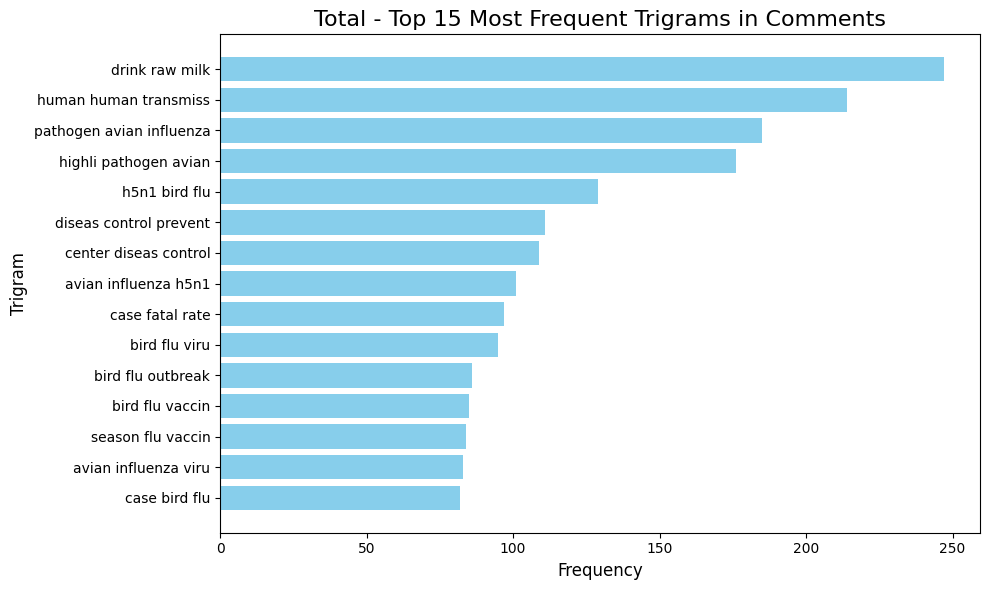

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# 1. Build trigram CountVectorizer
vectorizer = CountVectorizer(stop_words='english', ngram_range=(3, 3))

texts = combined['clean_comment_text'].dropna().apply(lambda x: ' '.join(x))

X = vectorizer.fit_transform(texts)

# 2. Sum trigram frequencies
word_freq_matrix = X.sum(axis=0).A1
trigrams = vectorizer.get_feature_names_out()

# 3. Create DataFrame
freq_df = pd.DataFrame({
    'trigram': trigrams,
    'count': word_freq_matrix
})

# 5. Take top 15 and plot
freq_top = freq_df.sort_values(by='count', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(freq_top['trigram'][::-1], freq_top['count'][::-1], color='skyblue')
plt.title('Total - Top 15 Most Frequent Trigrams in Comments', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Trigram', fontsize=12)
plt.tight_layout()
plt.show()

###Sentiment Analysis - Text2Emotion

This analysis will be completed using the Text2Emotion library. Text2Emotion expects natural sentences so we will not use the cleaned columns.

In [66]:
import pandas as pd

In [69]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.9 MB/s eta 0:00:00
Found existing installation: emoji 2.15.0
Uninstalling emoji-2.15.0:
  Successfully uninstalled emoji-2.15.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171031 sha256=4cdbcc1b20f9802832a2bec00c89c53a2deb23a6fafe9caf62407c64f6090cd3
  Stored in directory: /root/.cache/pip/wheels/e0/8c/e0/294d2e4ea0e55792bfc99b6b263e4a0511443da7b69af67688
Successfully built emoji


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [71]:
import text2emotion as te
import pandas as pd

# get per-row emotion dicts, then expand into columns
combined_emo_cols = combined['comment_body'].fillna('').apply(te.get_emotion).apply(pd.Series)
combined_emo_cols = combined_emo_cols[['Happy','Angry','Surprise','Sad','Fear']]

# attach to dataframe
combined = pd.concat([combined, combined_emo_cols], axis=1)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [72]:
top_surprise_comments = combined.sort_values(by='Surprise', ascending=False).head(5)

for i, comment in enumerate(top_surprise_comments['comment_body'], 1):
    print(f"{i}. {comment}\nSurprise Score: {top_surprise_comments['Surprise'].iloc[i-1]}")
    print("-" * 100)

1. Yup survival of the fittest at this point
Surprise Score: 1.0
----------------------------------------------------------------------------------------------------
2. I never yet responded to that - that's a good point of course!
Surprise Score: 1.0
----------------------------------------------------------------------------------------------------
3. Good point.
Surprise Score: 1.0
----------------------------------------------------------------------------------------------------
4. Seriously, any country could scam Trump out of billlons of dollars by selling snake oil and calling it “Ivermectin Pure”
Surprise Score: 1.0
----------------------------------------------------------------------------------------------------
5. You’d be better off with a terrier or a dog bred for hunting
Surprise Score: 1.0
----------------------------------------------------------------------------------------------------


In [73]:
# save as csv
combined.to_csv('complete_combined_with_t2e.csv', index=False)

In [75]:
combined_with_t2e=pd.read_csv('complete_combined_with_t2e.csv')

In [76]:
combined_with_t2e.head()

,subreddit,post_id,post_title,post_text,post_score,post_created_utc,comment_id,comment_body,comment_score,comment_created_utc,clean_post_text,clean_comment_text,is_moderator_comment,Happy,Angry,Surprise,Sad,Fear
0,Birdflu,10z8r3z,"['mani', 'earli', 'chinaflu', 'subreddit', 'ye...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j826b63,Ya man - I actually caught wind of covid Jan 1...,29,2023-02-11 01:52:53,"['give', 'seriou', 'deja', 'vu', 'vibe', 'arou...","['ya', 'man', 'actual', 'caught', 'wind', 'cov...",False,0.07,0.13,0.27,0.4,0.13
1,Birdflu,10z8r3z,"['mani', 'earli', 'chinaflu', 'subreddit', 'ye...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82jlm0,"Yeah, I was, but I was also early to /r/monkey...",28,2023-02-11 03:43:02,"['give', 'seriou', 'deja', 'vu', 'vibe', 'arou...","['yeah', 'also', 'earli', 'rmonkeypox', 'nt', ...",False,0.67,0.17,0.17,0.0,0.00
2,Birdflu,10z8r3z,"['mani', 'earli', 'chinaflu', 'subreddit', 'ye...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j8296o5,This was exactly what I was thinking just now ...,15,2023-02-11 02:15:52,"['give', 'seriou', 'deja', 'vu', 'vibe', 'arou...","['exactli', 'think', 'look', 'birdflu', 'sub']",False,0.00,0.00,0.00,0.0,0.00
3,Birdflu,10z8r3z,"['mani', 'earli', 'chinaflu', 'subreddit', 'ye...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82etwu,I was like the 75th person on ChinaFlu and am ...,12,2023-02-11 03:02:10,"['give', 'seriou', 'deja', 'vu', 'vibe', 'arou...","['like', '75th', 'person', 'chinaflu', 'defini...",False,0.33,0.33,0.00,0.0,0.33
4,Birdflu,10z8r3z,"['mani', 'earli', 'chinaflu', 'subreddit', 'ye...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82pkts,Yep. First I heard of it was 31st of December ...,12,2023-02-11 04:37:23,"['give', 'seriou', 'deja', 'vu', 'vibe', 'arou...","['yep', 'first', 'heard', '31st', 'decemb', 'r...",False,0.25,0.00,0.25,0.0,0.50


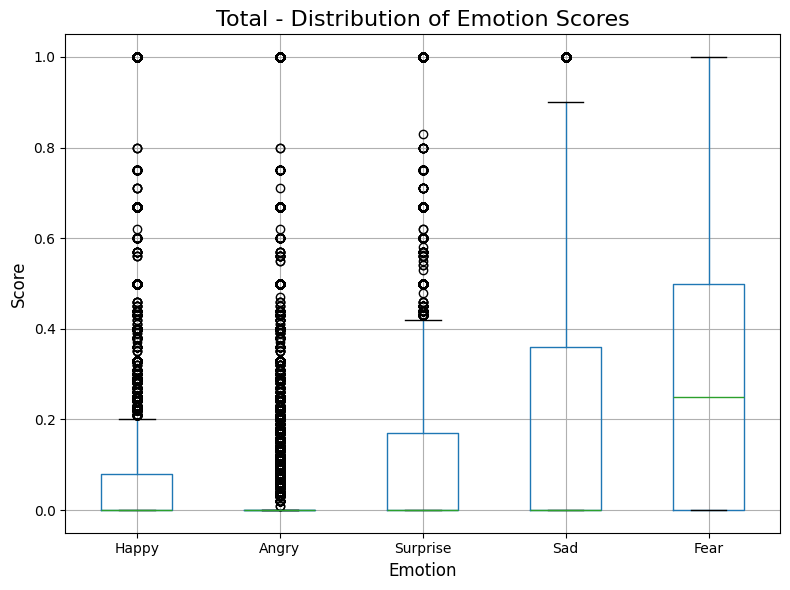

In [77]:
emotion_cols = ['Happy', 'Angry', 'Surprise', 'Sad', 'Fear']

# Create boxplot
plt.figure(figsize=(8, 6))
combined_with_t2e[emotion_cols].boxplot()

plt.title('Total - Distribution of Emotion Scores', fontsize=16)
plt.xlabel('Emotion', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.tight_layout()
plt.show()

In [78]:
df=pd.read_csv('complete_combined_with_t2e.csv')

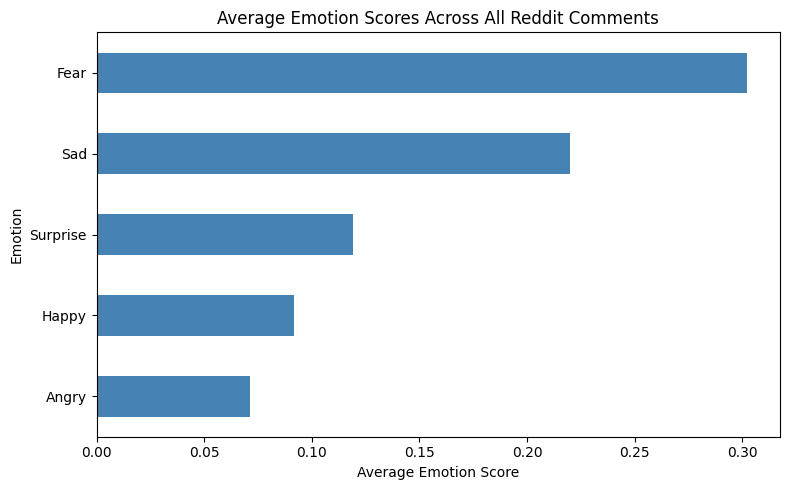

In [79]:
import matplotlib.pyplot as plt

emotion_cols = ['Happy', 'Angry', 'Surprise', 'Sad', 'Fear']

mean_emotions = df[emotion_cols].mean()

plt.figure(figsize=(8, 5))
mean_emotions.sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Emotion Scores Across All Reddit Comments')
plt.xlabel('Average Emotion Score')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()


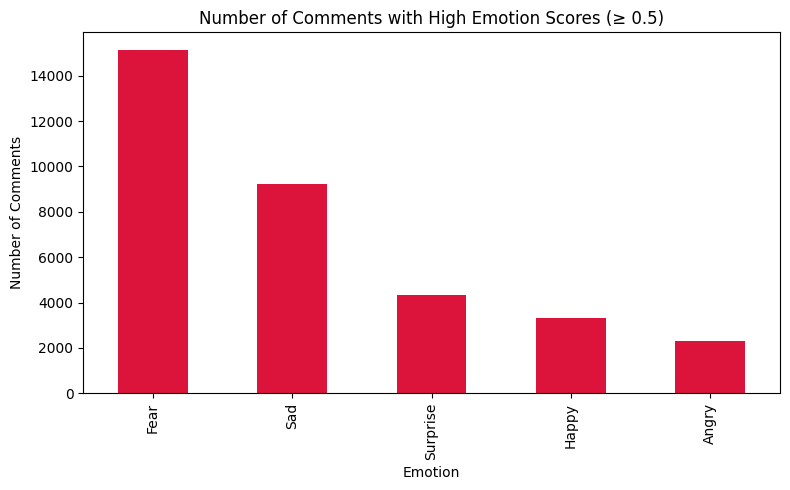

In [ ]:
# Threshold for "strong emotion"
threshold = 0.5

high_emotion_counts = {
    emotion: (df[emotion] >= threshold).sum()
    for emotion in emotion_cols
}

high_emotion_df = (
    pd.Series(high_emotion_counts)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
high_emotion_df.plot(kind='bar', color='crimson')
plt.title('Number of Comments with High Emotion Scores (≥ 0.5)')
plt.xlabel('Emotion')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()


###Toxicity - Google Perspective API Analysis

The Google Perspective API is a machine learning tool developed by Jigsaw and Google that detects toxic language in text by assigning a toxicity score. It analyzes content and rates how likely the language is to be perceived as rude, disrespectful, or likely to make someone leave a conversation. The model is trained on large datasets of human-rated text and uses natural language processing to classify words and phrases based on their semantic context, not just keyword matching. A higher score (closer to 1) indicates greater toxicity, while lower scores reflect more civil or neutral language. This API is commonly used to promote healthier discourse on online platforms.

In [82]:
# Setting API
API_KEY = 'YOUR_API_KEY_HERE'  # TODO: paste your Google Perspective API key (do not commit real keys)
PERSPECTIVE_URL = "https://commentanalyzer.googleapis.com/v1alpha1/comments:analyze"

In [83]:
import aiohttp
import asyncio

In [ ]:
import requests
import time

# Defining Toxicity Function
def get_toxicity(text, retries=3):
    headers = {
        'Content-Type': 'application/json'
    }
    data = {
        'comment': {'text': text},
        'languages': ['en'],
        'requestedAttributes': {'TOXICITY': {}}
    }

    for attempt in range(retries):
        try:
            response = requests.post(
                PERSPECTIVE_URL,
                headers=headers,
                params={'key': API_KEY},
                json=data
            )
            if response.status_code == 200:
                result = response.json()
                return result['attributeScores']['TOXICITY']['summaryScore']['value']
            else:
                print(f"API Error: {response.status_code}, Retrying...")
                time.sleep(1)
        except Exception as e:
            print(f"Error: {e}")
            time.sleep(1)

    return None

In [ ]:
# Use the all comments
subset = combined['comment_body']
# Apply and store toxicity scores
toxicity_scores = []
for i, comment in enumerate(subset):
  print(f"Analyzing comment {i + 1}/45759")
  score = get_toxicity(str(comment))
  toxicity_scores.append(score)
  time.sleep(1)

Streaming output truncated to the last 5000 lines.
Analyzing comment 15282/45759
Analyzing comment 15283/45759
Analyzing comment 15284/45759
Analyzing comment 15285/45759
Analyzing comment 15286/45759
Analyzing comment 15287/45759
Analyzing comment 15288/45759
Analyzing comment 15289/45759
Analyzing comment 15290/45759
Analyzing comment 15291/45759
Analyzing comment 15292/45759
Analyzing comment 15293/45759
Analyzing comment 15294/45759
Analyzing comment 15295/45759
Analyzing comment 15296/45759
Analyzing comment 15297/45759
Analyzing comment 15298/45759
Analyzing comment 15299/45759
Analyzing comment 15300/45759
Analyzing comment 15301/45759
Analyzing comment 15302/45759
Analyzing comment 15303/45759
Analyzing comment 15304/45759
Analyzing comment 15305/45759
Analyzing comment 15306/45759
Analyzing comment 15307/45759
Analyzing comment 15308/45759
Analyzing comment 15309/45759
Analyzing comment 15310/45759
Analyzing comment 15311/45759
Analyzing comment 15312/45759
Analyzing comment 1

In [ ]:
# Save results
df_googleperspective = combined.copy()
df_googleperspective['toxicity_score'] = toxicity_scores

# Save to CSV
df_googleperspective.to_csv("completedf_googleperspective.csv", index=False)
print("✅ Google Perspective Toxicity analysis complete and saved.")

In [84]:
df_googleperspective=pd.read_csv('df_googleperspective.csv')
df_googleperspective.head()

,subreddit,post_id,post_title,post_text,post_score,post_created_utc,comment_id,comment_body,comment_score,comment_created_utc,toxicity_score
0,Birdflu,10z8r3z,"How many of you were early in the ""ChinaFlu"" s...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j826b63,Ya man - I actually caught wind of covid Jan 1...,29,2023-02-11 01:52:53,0.073711
1,Birdflu,10z8r3z,"How many of you were early in the ""ChinaFlu"" s...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82jlm0,"Yeah, I was, but I was also early to /r/monkey...",28,2023-02-11 03:43:02,0.034984
2,Birdflu,10z8r3z,"How many of you were early in the ""ChinaFlu"" s...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j8296o5,This was exactly what I was thinking just now ...,15,2023-02-11 02:15:52,0.041668
3,Birdflu,10z8r3z,"How many of you were early in the ""ChinaFlu"" s...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82etwu,I was like the 75th person on ChinaFlu and am ...,12,2023-02-11 03:02:10,0.027560
4,Birdflu,10z8r3z,"How many of you were early in the ""ChinaFlu"" s...",This is giving me serious Deja Vu vibes - it w...,80,2023-02-11 01:30:17,j82pkts,Yep. First I heard of it was 31st of December ...,12,2023-02-11 04:37:23,0.518691


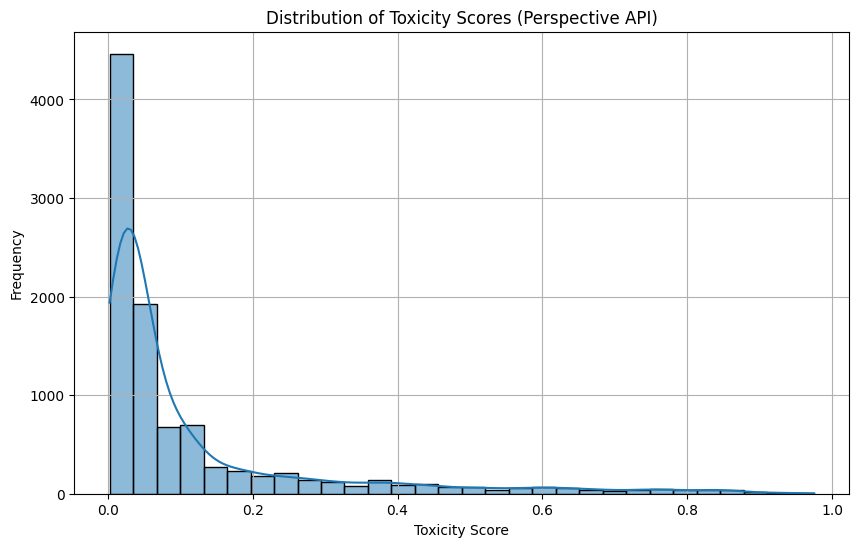

In [85]:
# Histogram of Toxity by Perpective API
plt.figure(figsize=(10, 6))
sns.histplot(df_googleperspective['toxicity_score'].dropna(), bins=30, kde=True)
plt.title('Distribution of Toxicity Scores (Perspective API)')
plt.xlabel('Toxicity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

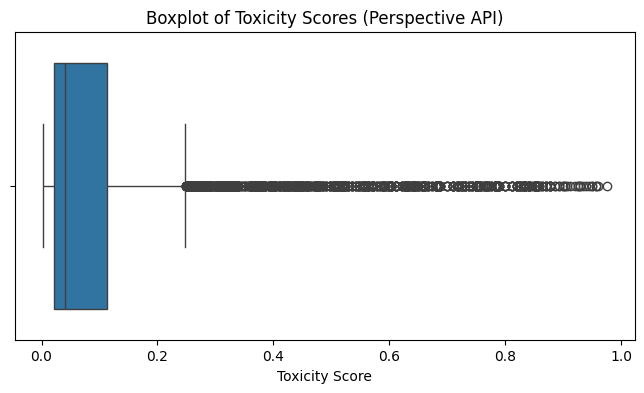

In [86]:
#Boxplot of Toxity by Perpective API
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_googleperspective['toxicity_score'])
plt.title('Boxplot of Toxicity Scores (Perspective API)')
plt.xlabel('Toxicity Score')
plt.show()

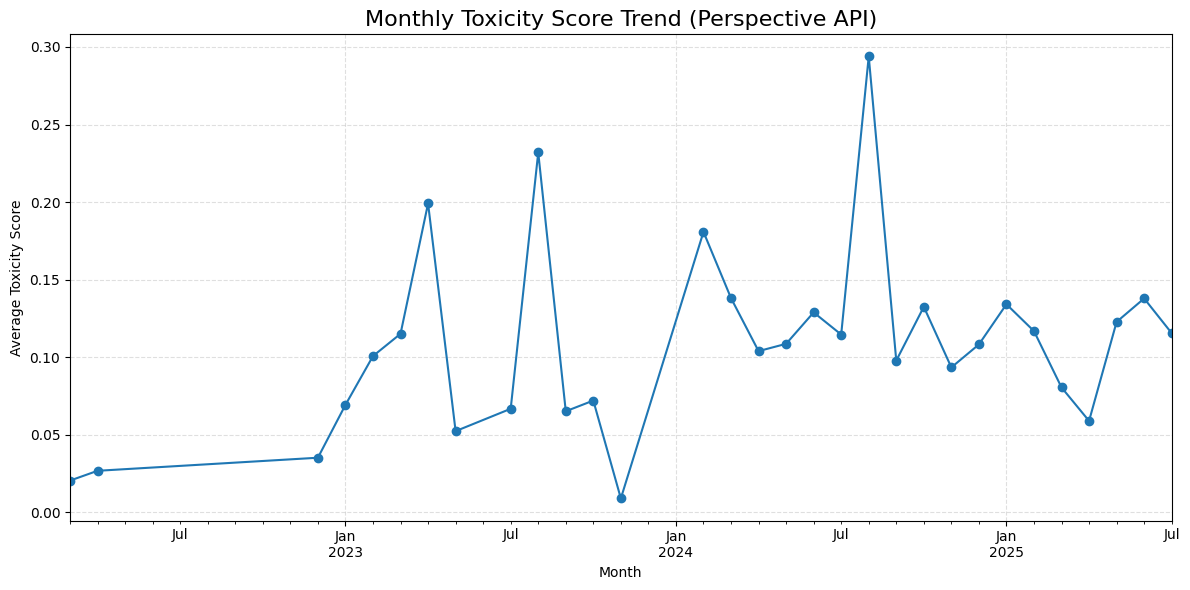

In [87]:
#Graph of Toxicity Perspective API through time
df_googleperspective['comment_created_utc'] = pd.to_datetime(df_googleperspective['comment_created_utc'])
df_googleperspective['month'] = df_googleperspective['comment_created_utc'].dt.to_period('M')
monthly_toxicity = df_googleperspective.groupby('month')['toxicity_score'].mean()
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
monthly_toxicity.plot(kind='line', marker='o')
plt.title('Monthly Toxicity Score Trend (Perspective API)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Toxicity Score')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

###Toxicity  - ToxicBERT

ToxicBERT is a transformer-based language model specifically fine-tuned to detect toxic language in online text. Built upon the widely-used BERT (Bidirectional Encoder Representations from Transformers) architecture developed by Google, ToxicBERT has been trained on datasets from online platforms, such as Reddit and Wikipedia, where human annotators have labeled comments for various forms of toxicity, including threats, insults, identity attacks, and general harmful content. Unlike traditional keyword-based models, ToxicBERT captures the contextual meaning of words within a sentence, making it more effective in detecting nuanced and implicit toxic expressions. It is widely used in content moderation, social media analysis, and online safety research due to its high performance and open accessibility via HuggingFace.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("unitary/toxic-bert")
model = AutoModelForSequenceClassification.from_pretrained("unitary/toxic-bert")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import torch
from scipy.special import softmax

# Defining Function to Get Toxicity Score
def get_toxicity_bert(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    scores = outputs[0][0].numpy()
    probabilities = softmax(scores)
    return float(probabilities[1])  # 1 = toxic class

In [ ]:
# Loading Dataset and Applying ToxicBERT
df_toxicity_bert = combined.copy()
df_toxicity_bert['toxicity_score_bert'] = df_toxicity_bert['comment_body'].astype(str).apply(get_toxicity_bert)

# Save to CSV
df_toxicity_bert.to_csv("df_toxicity_toxicbert.csv", index=False)
print("✅ ToxicBERT toxicity analysis complete and saved.")

✅ ToxicBERT toxicity analysis complete and saved.


In [89]:
df_toxicity_toxicbert = pd.read_csv('df_toxicity_toxicbert.csv')

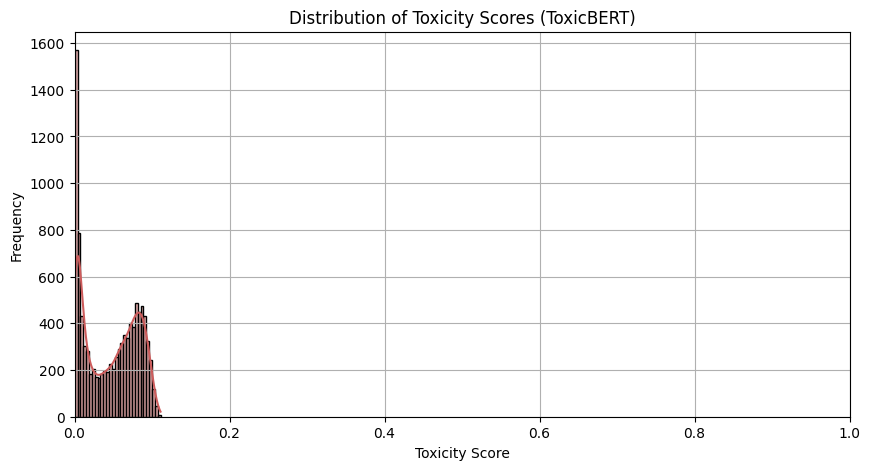

In [90]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df_toxicity_toxicbert['toxicity_score_bert'], bins=30, kde=True, color='indianred')
plt.title('Distribution of Toxicity Scores (ToxicBERT)')
plt.xlabel('Toxicity Score')
plt.ylabel('Frequency')
plt.xlim(0, 1)
plt.grid(True)
plt.show()

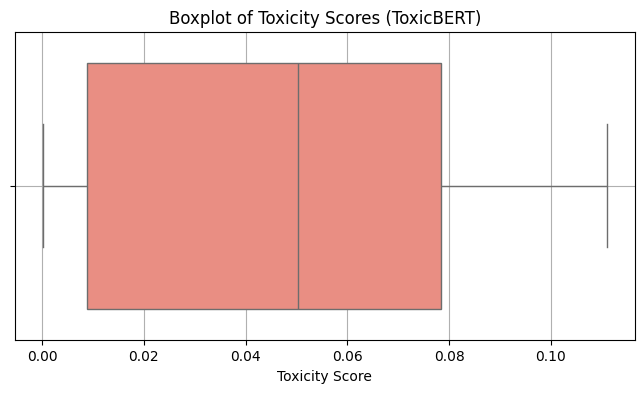

In [91]:
# Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_toxicity_toxicbert['toxicity_score_bert'], color='salmon')
plt.title('Boxplot of Toxicity Scores (ToxicBERT)')
plt.xlabel('Toxicity Score')
plt.grid(True)
plt.show()

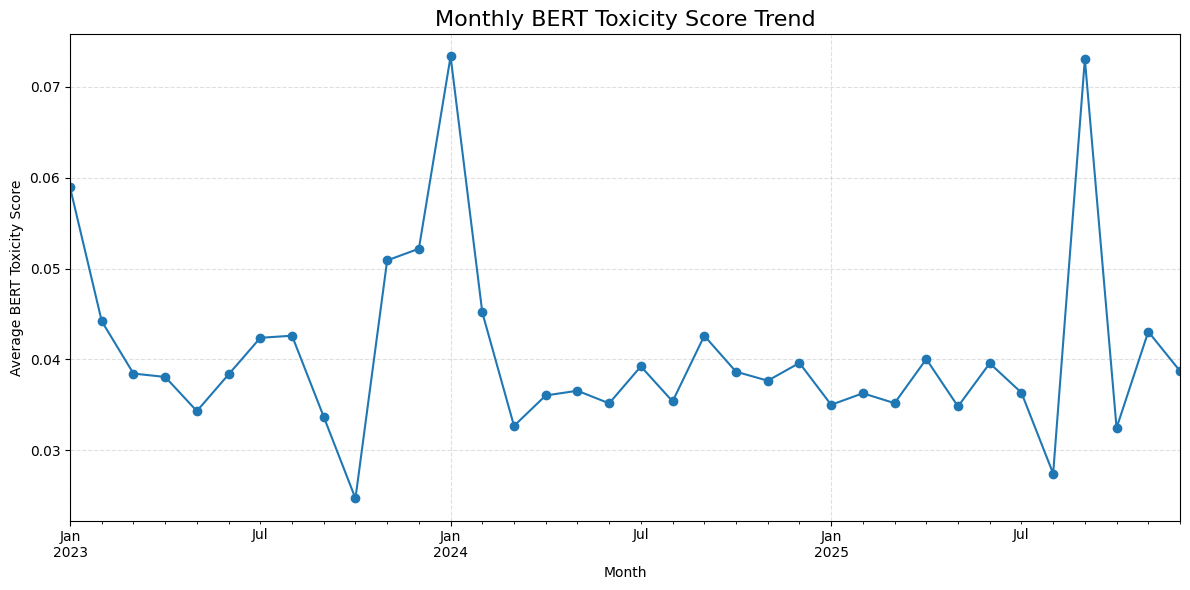

In [ ]:
df_toxicity_bert['month'] = df_toxicity_bert['comment_created_utc'].dt.to_period('M')
monthly_toxicity_bert = df_toxicity_bert.groupby('month')['toxicity_score_bert'].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
monthly_toxicity_bert.plot(kind='line', marker='o')
plt.title('Monthly BERT Toxicity Score Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average BERT Toxicity Score')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


###Topic Modeling - LDA

Latent Dirichlet Allocation (LDA) — one of the most popular unsupervised learning algorithms for discovering abstract topics in a large collection of text. Each topic is represented by a set of keywords, and each comment is modeled as a mixture of these topics.

https://www.ibm.com/think/topics/latent-dirichlet-allocation

In [92]:
combined.shape

(45759, 18)

In [93]:
subset = combined['clean_comment_text'].head(45759).copy()
df_topicmodeling = pd.DataFrame(subset).rename(columns={'clean_comment_text': 'text'})

In [95]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# STEP 4: Vectorize the text
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
dtm = vectorizer.fit_transform(df_topicmodeling['text'].apply(lambda x: ' '.join(x)))

# STEP 5: Apply LDA
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

# STEP 6: Display top words per topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n Topic #{topic_idx + 1}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

print_top_words(lda, vectorizer.get_feature_names_out(), 10)

# STEP 7: Assign dominant topic to each document
topic_values = lda.transform(dtm)
df_topicmodeling['dominant_topic'] = topic_values.argmax(axis=1)

# Done
print("\n Topic modeling complete. 'df_topicmodeling' is ready.")


 Topic #1:
nt, peopl, covid, like, think, vaccin, know, time, thing, make

 Topic #2:
human, flu, infect, viru, bird, h5n1, case, test, spread, mutat

 Topic #3:
milk, raw, cat, farm, food, cow, nt, dairi, anim, chicken

 Topic modeling complete. 'df_topicmodeling' is ready.


##Relational Analysis

### Reddit Comments Over Time

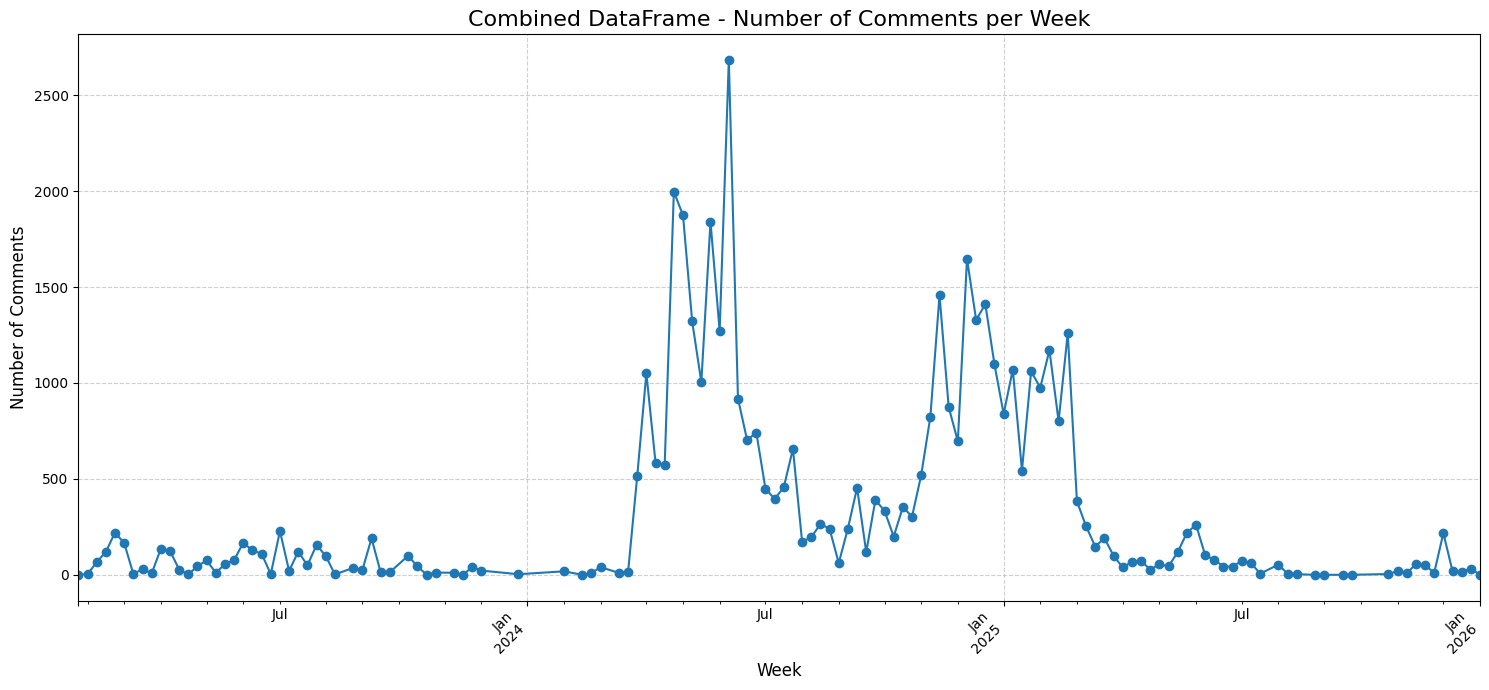

In [96]:
import matplotlib.pyplot as plt

# Ensure 'comment_created_utc' is a datetime object
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

# Aggregate comments by week
weekly_comments = combined.groupby(combined['comment_created_utc'].dt.to_period('W')).size()

# Plot the weekly comments
plt.figure(figsize=(15, 7))
weekly_comments.plot(kind='line', marker='o', linestyle='-')
plt.title('Combined DataFrame - Number of Comments per Week', fontsize=16)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

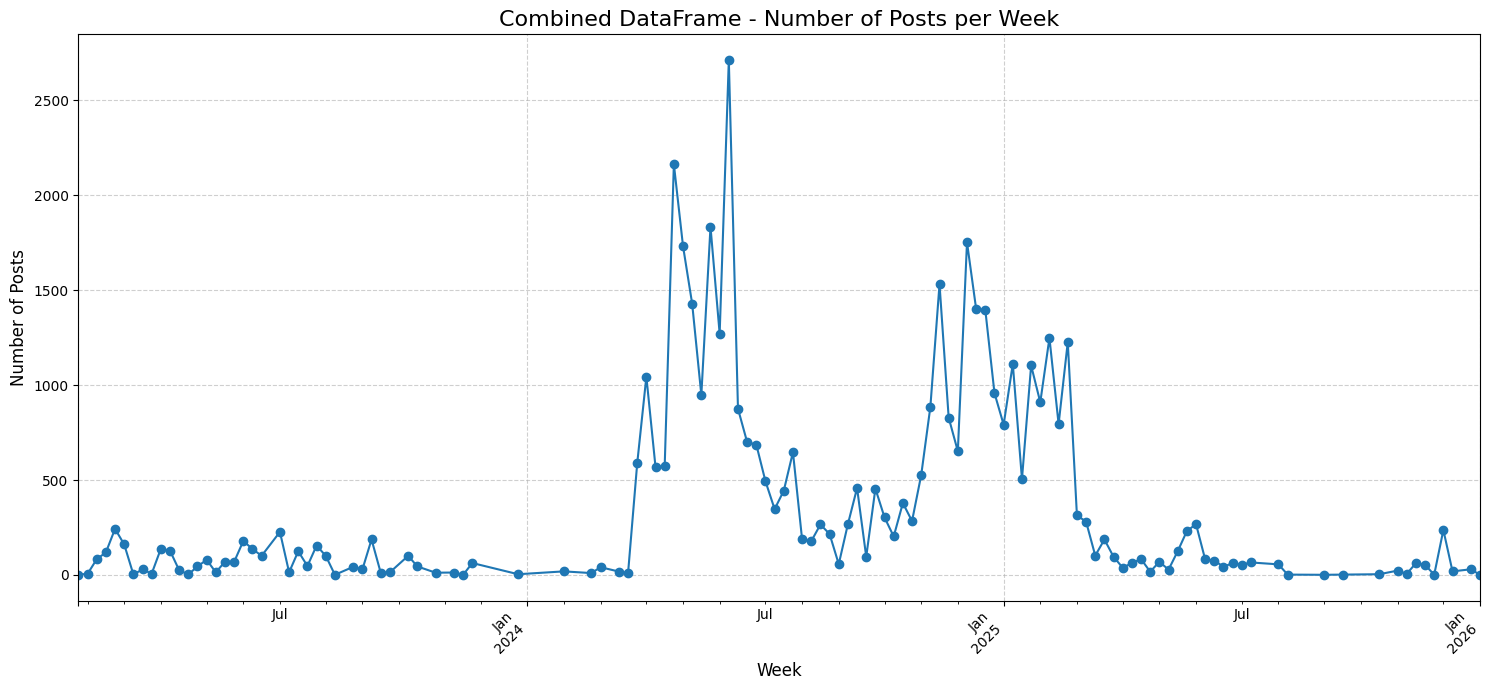

In [97]:
import matplotlib.pyplot as plt

# Ensure 'comment_created_utc' is a datetime object
combined['post_created_utc'] = pd.to_datetime(combined['post_created_utc'], errors='coerce')

# Aggregate comments by week
weekly_posts = combined.groupby(combined['post_created_utc'].dt.to_period('W')).size()

# Plot the weekly comments
plt.figure(figsize=(15, 7))
weekly_posts.plot(kind='line', marker='o', linestyle='-')
plt.title('Combined DataFrame - Number of Posts per Week', fontsize=16)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

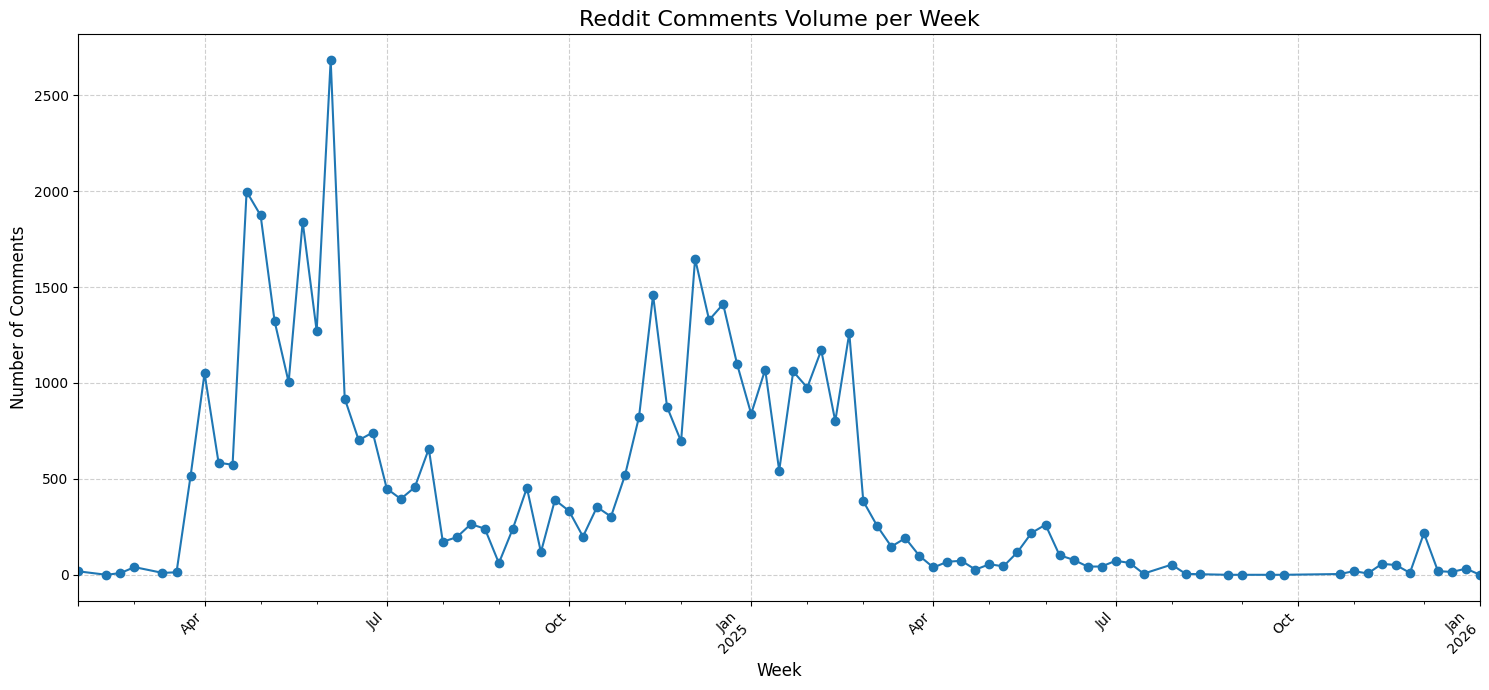

In [98]:
import matplotlib.pyplot as plt

# Ensure 'comment_created_utc' is a datetime object
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

# Aggregate comments by week
weekly_comments = combined.groupby(combined['comment_created_utc'].dt.to_period('W')).size()

# Filter data to start from January 2024
weekly_comments_filtered = weekly_comments[weekly_comments.index >= '2024-01-01']

# Plot the filtered weekly comments
plt.figure(figsize=(15, 7))
weekly_comments_filtered.plot(kind='line', marker='o', linestyle='-')
plt.title('Reddit Comments Volume per Week', fontsize=16)
plt.xlabel('Week', fontsize=12)
plt.ylabel('Number of Comments', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Cuts CSV

In [99]:
cuts=pd.read_csv("cuts.csv")
cuts.head()

,Year,Month,Month_Number,Data_Item,Value,Units,Source
0,2023,August,8.0,Ground chuck retail price,5.259,Dollars per pound,BLS
1,2023,September,9.0,Ground chuck retail price,5.185,Dollars per pound,BLS
2,2023,October,10.0,Ground chuck retail price,5.349,Dollars per pound,BLS
3,2023,November,11.0,Ground chuck retail price,5.201,Dollars per pound,BLS
4,2023,December,12.0,Ground chuck retail price,5.118,Dollars per pound,BLS


In [100]:
cuts['Data_Item'].unique()

array(['Ground chuck retail price', 'Ground beef retail price',
       'Lean & extra lean ground beef retail price',
       'All uncooked ground beef retail price',
       'Chuck roast, USDA Choice, boneless retail price',
       'Round roast, USDA Choice boneless retail price',
       'Round steak, USDA Choice retail price',
       'All uncooked beef roasts retail price',
       'Sirloin steak, USDA Choice boneless retail price',
       'Beef for stew, boneless retail price',
       'All uncooked beef steaks retail price',
       'All uncooked other beef not veal retail price',
       'Bacon, sliced retail price',
       'Pork chops, center cut, bone in retail price',
       'Pork chops, boneless, retail price',
       'All pork chops retail price',
       'Ham, boneless not canned retail price',
       'All ham (not canned or sliced) retail price',
       'All other pork excluding canned & sliced retail price',
       'Retail broiler composite', 'Wholesale broiler composite',
       

In [101]:
cuts['Year'].unique()

array(['2023', '2024', '2025', nan,
       'Source: "BLS" are average prices reported by the U.S. Department of Labor, Bureau of Labor Statistics (BLS). "AMS" are data reported by the USDA Agricultural Marketing Service. "ERS" are USDA, Economic Research Service calculations based on BLS and AMS data.'],
      dtype=object)

In [102]:
cuts['Month_Number'].unique()

array([ 8.,  9., 10., 11., 12.,  1.,  2.,  3.,  4.,  5.,  6.,  7., nan])

In [103]:
cuts.dtypes

,0
Year,object
Month,object
Month_Number,float64
Data_Item,object
Value,float64
Units,object
Source,object


In [104]:
cuts.isna().sum()

,0
Year,1
Month,2
Month_Number,2
Data_Item,2
Value,2
Units,2
Source,2


In [105]:
# Drop rows with any NaN values in relevant columns to ensure clean conversion
cuts = cuts.dropna(subset=['Year', 'Month', 'Month_Number']).copy()

# Now convert to integer types
cuts['Month_Number'] = cuts['Month_Number'].astype(int)
cuts['Year'] = cuts['Year'].astype(int)

In [106]:
# Uniting Year and Month
cuts['date'] = pd.to_datetime(
    cuts['Year'].astype(int).astype(str) + '-' + cuts['Month_Number'].astype(int).astype(str) + '-01'
)

In [107]:
cuts.head()

,Year,Month,Month_Number,Data_Item,Value,Units,Source,date
0,2023,August,8,Ground chuck retail price,5.259,Dollars per pound,BLS,2023-08-01
1,2023,September,9,Ground chuck retail price,5.185,Dollars per pound,BLS,2023-09-01
2,2023,October,10,Ground chuck retail price,5.349,Dollars per pound,BLS,2023-10-01
3,2023,November,11,Ground chuck retail price,5.201,Dollars per pound,BLS,2023-11-01
4,2023,December,12,Ground chuck retail price,5.118,Dollars per pound,BLS,2023-12-01


In [108]:
items = [
    'Chicken, fresh whole retail price',
    'Chicken legs bone-in retail price',
    'Chicken boneless breast retail price',
    'Eggs, Grade A large retail price',
    'Eggs, Grade A large wholesale price',
    'Milk, fresh, whole, fortified-gallon retail price',
    'American processed cheese retail price',
       'Cheddar cheese, natural retail price',
       'Ice cream, prepackaged  retail price'
]

df_items = cuts[cuts['Data_Item'].isin(items)]


In [109]:
pivot_df = df_items.pivot_table(
    index='date',
    columns='Data_Item',
    values='Value'
).sort_index()


In [110]:
pivot_df.head()

Data_Item,American processed cheese retail price,"Cheddar cheese, natural retail price",Chicken boneless breast retail price,Chicken legs bone-in retail price,"Chicken, fresh whole retail price","Eggs, Grade A large retail price","Eggs, Grade A large wholesale price","Ice cream, prepackaged retail price","Milk, fresh, whole, fortified-gallon retail price"
date,,,,,,,,,
2023-08-01,4.730,5.897,4.179,2.031,1.958,2.043,1.305,5.904,3.927
2023-09-01,4.767,5.846,4.229,1.899,1.901,2.065,1.467,5.959,3.965
2023-10-01,4.738,5.846,4.222,1.917,1.926,2.072,1.242,6.041,3.927
2023-11-01,4.748,5.650,4.060,1.851,1.976,2.138,1.910,6.014,3.997
2023-12-01,4.956,5.545,4.082,1.856,1.955,2.507,1.982,6.015,4.008


In [111]:
print(f"Date range of cuts: {cuts['date'].min()} to {cuts['date'].max()}")

Date range of cuts: 2023-08-01 00:00:00 to 2025-08-01 00:00:00


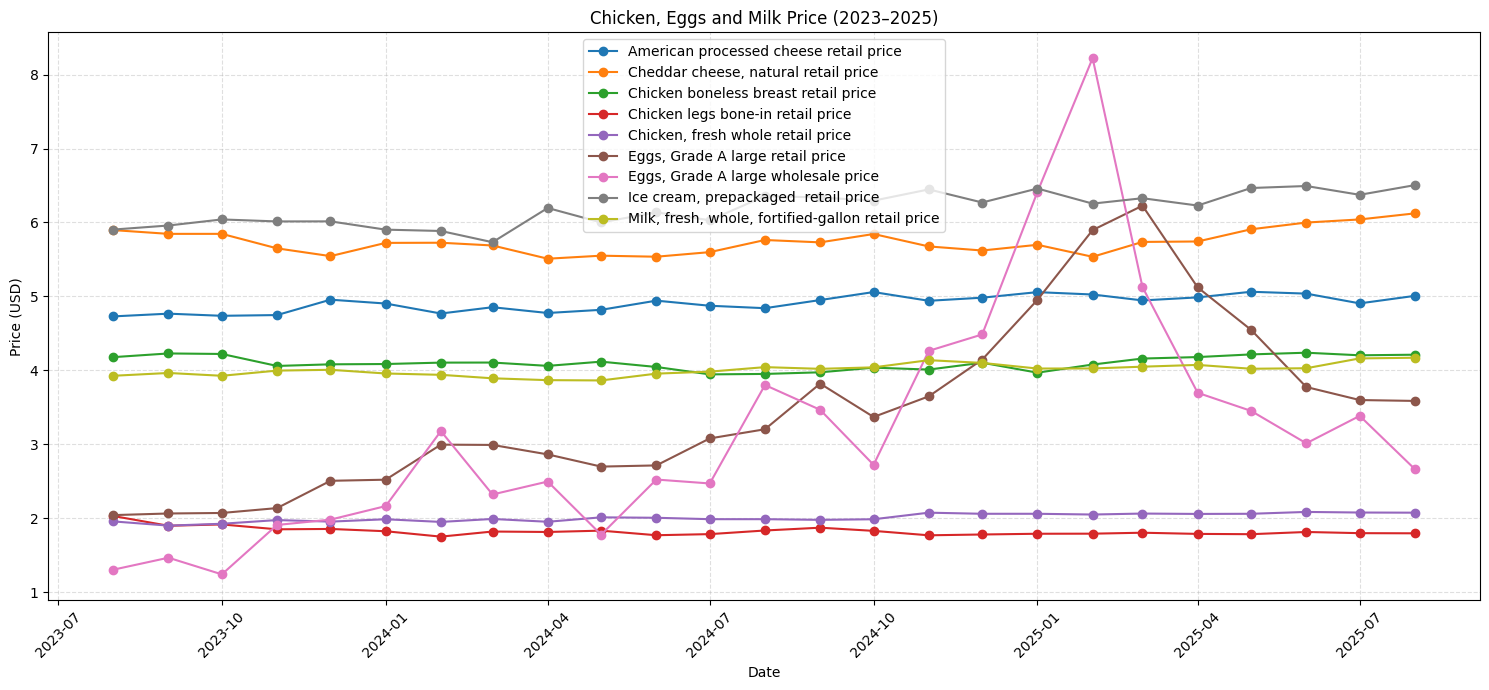

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], marker='o', label=col)

plt.title('Chicken, Eggs and Milk Price (2023–2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [114]:
second_items = [ 'Ground chuck retail price', 'Ground beef retail price',
       'Lean & extra lean ground beef retail price',
       'All uncooked ground beef retail price',
       'Chuck roast, USDA Choice, boneless retail price',
       'Round roast, USDA Choice boneless retail price',
       'Round steak, USDA Choice retail price',
       'All uncooked beef roasts retail price',
       'Sirloin steak, USDA Choice boneless retail price',
       'Beef for stew, boneless retail price',
       'All uncooked beef steaks retail price',
       'All uncooked other beef not veal retail price',
       'Bacon, sliced retail price',
       'Pork chops, center cut, bone in retail price',
       'Pork chops, boneless, retail price',
       'All pork chops retail price',
       'Ham, boneless not canned retail price',
       'All ham (not canned or sliced) retail price',
       'All other pork excluding canned & sliced retail price',
       'Retail broiler composite', 'Wholesale broiler composite',
       'Wholesale-retail broiler spread'
       ]

seconddf_items = cuts[cuts['Data_Item'].isin(second_items)]


In [115]:
secondpivot_df = seconddf_items.pivot_table(
    index='date',
    columns='Data_Item',
    values='Value'
).sort_index()


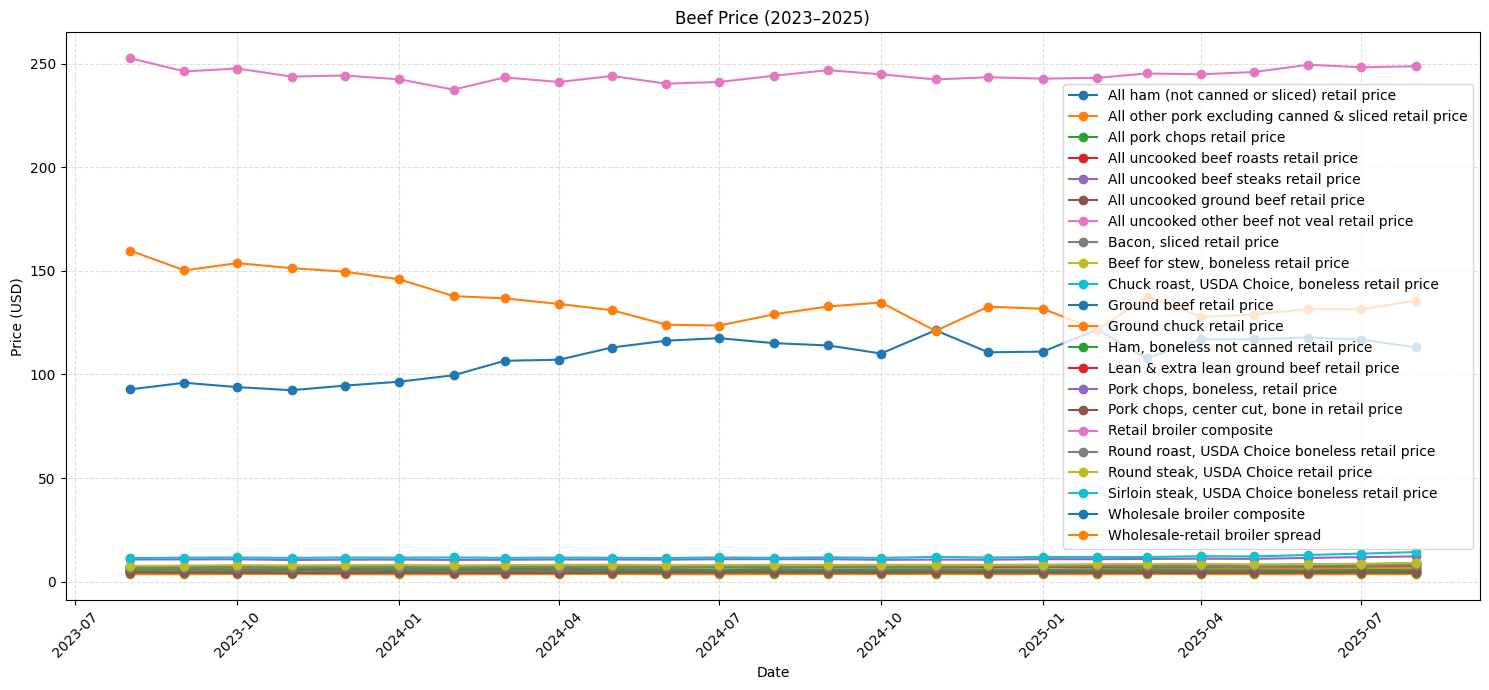

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

for col in secondpivot_df.columns:
    plt.plot(secondpivot_df.index, secondpivot_df[col], marker='o', label=col)

plt.title('Beef Price (2023–2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only egg items
egg_items = [
    'Eggs, Grade A large retail price',
    'Eggs, Grade A large wholesale price'
]

cuts_eggs = cuts[cuts['Data_Item'].isin(egg_items)].copy()

# Build a proper date column from Year + Month_Number
cuts_eggs['date'] = pd.to_datetime(
    cuts_eggs['Year'].astype(int).astype(str) + '-' +
    cuts_eggs['Month_Number'].astype(int).astype(str) + '-01'
)

# (Optional) restrict to 2023–2025
cuts_eggs = cuts_eggs[(cuts_eggs['Year'] >= 2023) & (cuts_eggs['Year'] <= 2025)]

# Pivot so each egg series is a column
eggs_monthly = cuts_eggs.pivot_table(
    index='date',
    columns='Data_Item',
    values='Value'
).sort_index()


In [118]:
# Make sure post_created_utc is datetime
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

# Group by month and count posts
posts_monthly = (
    combined
    .groupby(combined['comment_created_utc'].dt.to_period('M'))
    .size()
    .to_frame('comment_count')
)

# Convert PeriodIndex to Timestamp for alignment with eggs_monthly
posts_monthly.index = posts_monthly.index.to_timestamp()


In [119]:
# Join on date index
merged = eggs_monthly.join(posts_monthly, how='inner').dropna(subset=['comment_count'])
merged.head()


,"Eggs, Grade A large retail price","Eggs, Grade A large wholesale price",comment_count
2023-08-01,2.043,1.305,141
2023-09-01,2.065,1.467,240
2023-10-01,2.072,1.242,159
2023-11-01,2.138,1.910,77
2023-12-01,2.507,1.982,5


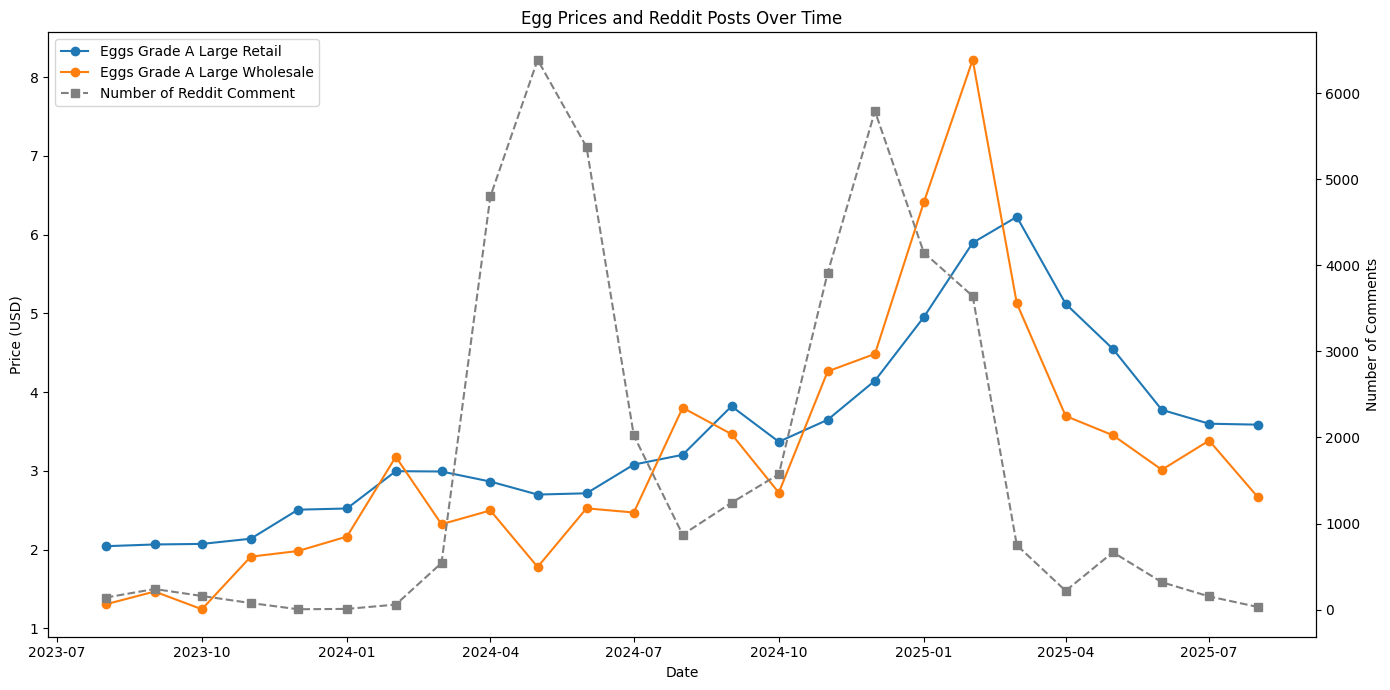

In [120]:
plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Plot egg prices on left y-axis
ax1.plot(
    merged.index,
    merged['Eggs, Grade A large retail price'],
    marker='o',
    label='Eggs Grade A Large Retail'
)
ax1.plot(
    merged.index,
    merged['Eggs, Grade A large wholesale price'],
    marker='o',
    label='Eggs Grade A Large Wholesale'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')
ax1.set_title('Egg Prices and Reddit Posts Over Time')

# Create second y-axis for post count
ax2 = ax1.twinx()
ax2.plot(
    merged.index,
    merged['comment_count'],
    marker='s',
    linestyle='--',
    color='gray',
    label='Number of Reddit Comment'
)
ax2.set_ylabel('Number of Comments')
ax2.tick_params(axis='y')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###Wild Bird Cases

In [122]:
df_wild=pd.read_csv("HPAI Detections in Wild Birds (2).csv")
df_wild.head()

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency
0,California,Solano,2/24/2026,4/29/2026,EA H5,Great horned owl,Wild bird,Morbidity/Mortality,CA DFW/CAHFS
1,California,Placer,4/15/2026,4/29/2026,EA H5,Snow goose,Wild bird,Morbidity/Mortality,CA DFW/CAHFS
2,California,Placer,4/15/2026,4/29/2026,EA H5,Snow goose,Wild bird,Morbidity/Mortality,CA DFW/CAHFS
3,California,Placer,4/15/2026,4/29/2026,EA H5,Snow goose,Wild bird,Morbidity/Mortality,CA DFW/CAHFS
4,California,San Mateo,4/13/2026,4/29/2026,EA H5N1,Herring gull,Wild bird,Morbidity/Mortality,CA DFW/CAHFS


In [123]:
df_wild.shape

(19400, 9)

In [124]:
df_wild['WOAH Classification'].unique()

array(['Wild bird', 'Captive wild bird', 'Wild Bird'], dtype=object)

In [125]:
df_wild.dtypes

,0
State,object
County,object
Collection Date,object
Date Detected,object
HPAI Strain,object
Bird Species,object
WOAH Classification,object
Sampling Method,object
Submitting Agency,object


In [126]:
df_wild['Date Detected'] = pd.to_datetime(df_wild['Date Detected'], errors='coerce')


In [127]:
print(f"Date range of df_wild: {df_wild['Date Detected'].min()} to {df_wild['Date Detected'].max()}")

Date range of df_wild: 2022-01-12 00:00:00 to 2026-04-29 00:00:00


In [128]:
df_wild.isna().sum()

,0
State,0
County,0
Collection Date,0
Date Detected,0
HPAI Strain,0
Bird Species,0
WOAH Classification,0
Sampling Method,0
Submitting Agency,0


In [129]:
df_wild['WOAH Classification'].value_counts()

,count
WOAH Classification,
Wild bird,18464
Captive wild bird,929
Wild Bird,7


In [130]:
df_wild['Date Detected'].dtypes

dtype('<M8[ns]')

In [131]:
df_wild['week'] = df_wild['Date Detected'].dt.to_period('W').dt.start_time

wild_weekly = df_wild.groupby('week').size().to_frame('wild_detections')
wild_weekly.head()


,wild_detections
week,
2022-01-10,6
2022-01-17,37
2022-01-24,37
2022-01-31,11
2022-02-07,49


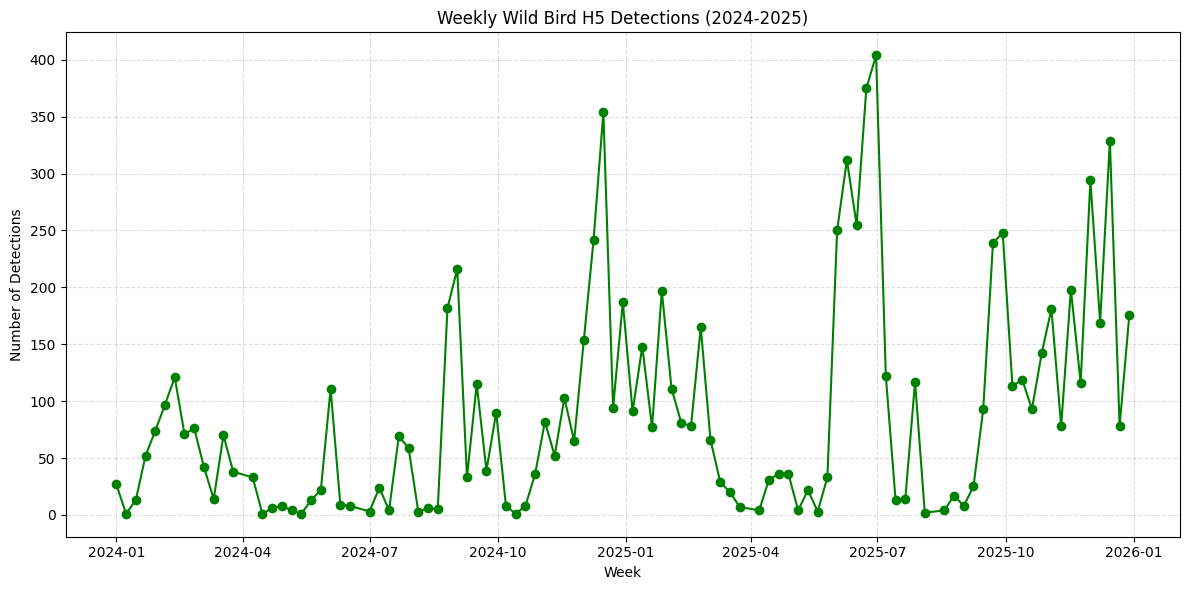

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter wild_weekly for the desired date range
wild_weekly_filtered = wild_weekly[(wild_weekly.index >= '2024-01-01') & (wild_weekly.index <= '2025-12-31')]

plt.figure(figsize=(12, 6))
plt.plot(wild_weekly_filtered.index, wild_weekly_filtered['wild_detections'], marker='o', color='green')
plt.title('Weekly Wild Bird H5 Detections (2024-2025)')
plt.xlabel('Week')
plt.ylabel('Number of Detections')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [133]:
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

combined['week'] = combined['comment_created_utc'].dt.to_period('W').dt.start_time

reddit_weekly = (
    combined.groupby('week')
    .size()
    .to_frame('comment_count')
)


In [134]:
merged_wild = wild_weekly.join(reddit_weekly, how='inner')
merged_wild.head()


,wild_detections,comment_count
week,,
2023-01-23,95,2
2023-01-30,63,4
2023-02-06,63,67
2023-02-13,93,121
2023-02-20,41,221


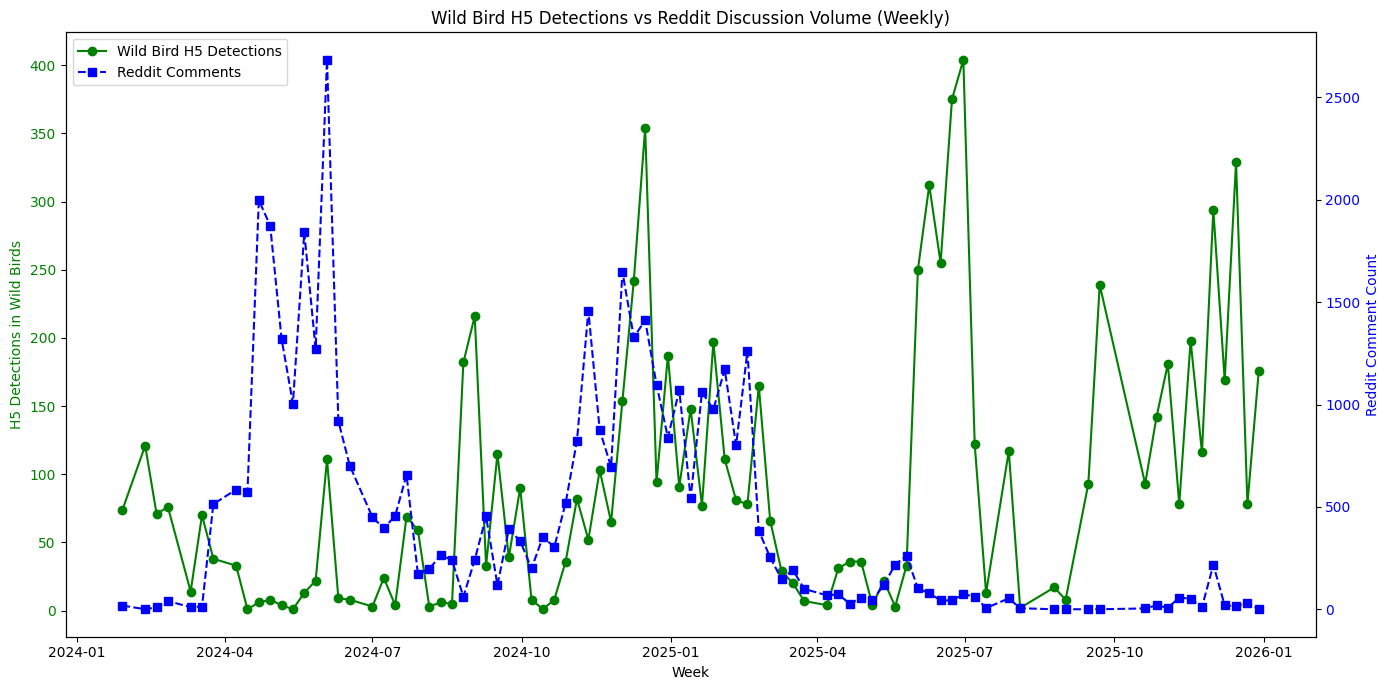

In [135]:
import matplotlib.pyplot as plt

# Filter merged_wild for the desired date range
merged_wild_filtered = merged_wild[(merged_wild.index >= '2024-01-01') & (merged_wild.index <= '2025-12-31')]

plt.figure(figsize=(14,7))
ax1 = plt.gca()

# Plot wild detections (left axis)
ax1.plot(merged_wild_filtered.index, merged_wild_filtered['wild_detections'], marker='o', color='green', label='Wild Bird H5 Detections')
ax1.set_ylabel('H5 Detections in Wild Birds', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Week')

# Plot Reddit comments (right axis)
ax2 = ax1.twinx()
ax2.plot(merged_wild_filtered.index, merged_wild_filtered['comment_count'], marker='s', linestyle='--', color='blue', label='Reddit Comments')
ax2.set_ylabel('Reddit Comment Count', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Wild Bird H5 Detections vs Reddit Discussion Volume (Weekly)')
plt.tight_layout()
plt.show()

### Google News Articles

In [136]:
df_news=pd.read_csv("serpapi_birdflu_news.csv")
df_news.head()

,date,fetched_at_utc,link,position,published_at,snippet,source,thumbnail,title,window_end,window_start
0,"Jan 31, 2024",2026-01-13T16:49:36.472539,https://news.mongabay.com/2024/01/in-argentina...,1,2024-01-31 08:00:00 UTC,A powerful strain of the avian flu has swept t...,Mongabay,https://serpapi.com/searches/69666ff5f357f6c2d...,"In Argentina, scientists scramble to study sea...",2024-01-31,2024-01-01
1,"Jan 31, 2024",2026-01-13T16:49:36.472539,https://www.science.org/doi/10.1126/sciadv.adj...,3,2024-01-31 08:00:00 UTC,Avian ANP32A (avANP32A) delivered by avian inf...,Science | AAAS,https://serpapi.com/searches/69666ff5f357f6c2d...,Avian ANP32A incorporated in avian influenza A...,2024-01-31,2024-01-01
2,"Jan 31, 2024",2026-01-13T16:49:36.472539,https://www.freemalaysiatoday.com/category/wor...,4,2024-01-31 08:00:00 UTC,China on Wednesday reported the death of a wom...,Free Malaysia Today,https://serpapi.com/searches/69666ff5f357f6c2d...,"Chinese woman dies from combined H3N2, H10N5 b...",2024-01-31,2024-01-01
3,"Jan 31, 2024",2026-01-13T16:49:36.472539,https://www.thenewdaily.com.au/news/world/2024...,5,2024-01-31 08:00:00 UTC,Samples taken from two penguins found dead in ...,The New Daily,https://serpapi.com/searches/69666ff5f357f6c2d...,"Bird flu found in Falkland Islands, 35 penguin...",2024-01-31,2024-01-01
4,"Jan 31, 2024",2026-01-13T16:49:36.472539,https://m.dongascience.com/en/news/63592,6,2024-01-31 08:00:00 UTC,When ferrets were co-infected with equal amoun...,동아사이언스,https://serpapi.com/searches/69666ff5f357f6c2d...,Mutated 'H5N1' Highly Pathogenic Avian Flu in ...,2024-01-31,2024-01-01


In [137]:
df_news.shape

(4892, 11)

In [138]:
df_news.dtypes

,0
date,object
fetched_at_utc,object
link,object
position,int64
published_at,object
snippet,object
source,object
thumbnail,object
title,object
window_end,object


In [139]:
df_news['published_at'] = (
    df_news['published_at']
    .str.replace(" UTC", "", regex=False)
)

df_news['published_at'] = pd.to_datetime(df_news['published_at'], errors='coerce')


In [140]:
df_news['week'] = df_news['published_at'].dt.to_period('W').dt.start_time

news_weekly = (
    df_news.groupby('week')
    .size()
    .to_frame('article_count')
)


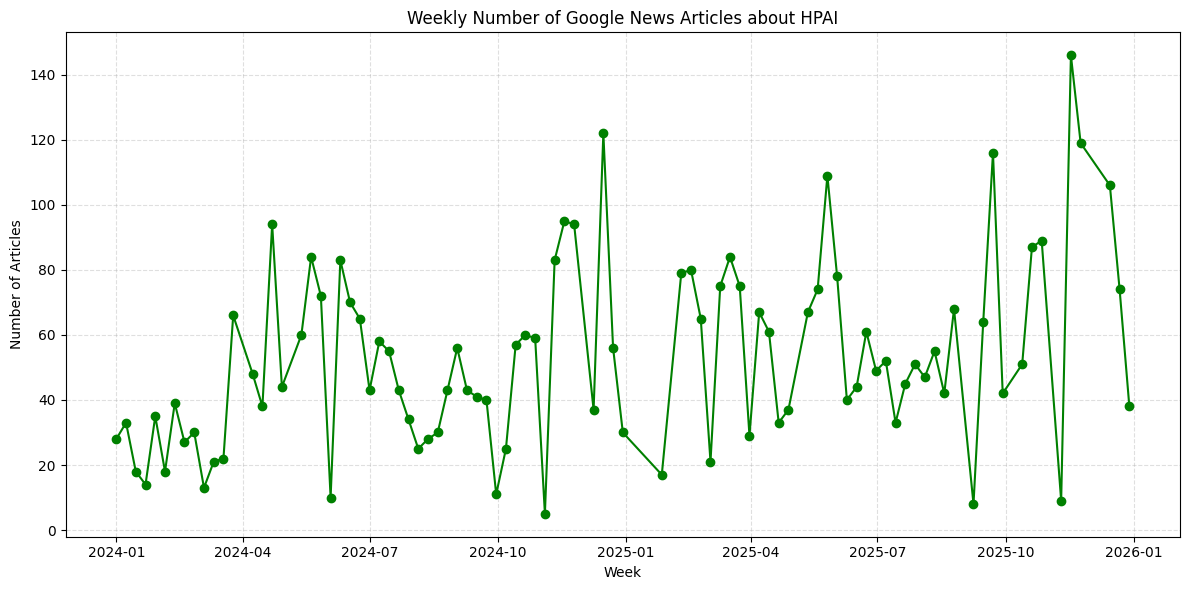

In [141]:
plt.figure(figsize=(12, 6))
plt.plot(news_weekly.index, news_weekly['article_count'], marker='o', color='green')
plt.title('Weekly Number of Google News Articles about HPAI')
plt.xlabel('Week')
plt.ylabel('Number of Articles')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [142]:
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

combined['week'] = combined['comment_created_utc'].dt.to_period('W').dt.start_time

reddit_weekly = (
    combined.groupby('week')
    .size()
    .to_frame('comment_count')
)


In [143]:
merged_news = news_weekly.join(reddit_weekly, how='inner')
merged_news.head()


,article_count,comment_count
week,,
2024-01-29,35,19
2024-02-12,39,1
2024-02-19,27,10
2024-02-26,30,41
2024-03-11,21,11


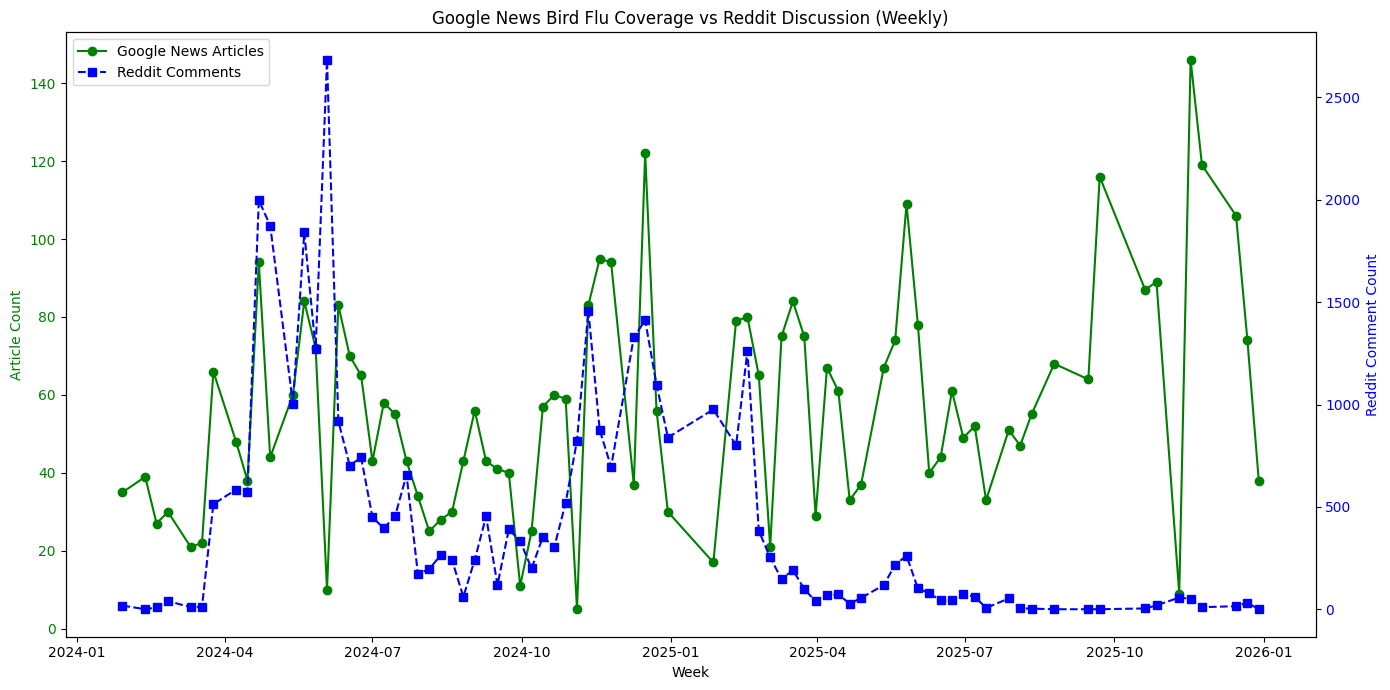

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Plot news articles on left axis
ax1.plot(
    merged_news.index,
    merged_news['article_count'],
    marker='o',
    color='green',
    label='Google News Articles'
)
ax1.set_ylabel('Article Count', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xlabel('Week')

# Plot Reddit comments on right axis
ax2 = ax1.twinx()
ax2.plot(
    merged_news.index,
    merged_news['comment_count'],
    marker='s',
    linestyle='--',
    color='blue',
    label='Reddit Comments'
)
ax2.set_ylabel('Reddit Comment Count', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Google News Bird Flu Coverage vs Reddit Discussion (Weekly)')
plt.tight_layout()
plt.show()


### Poultry Cases

In [145]:
poultry_df=pd.read_csv('poultry_confirmed_cases.csv')
poultry_df

,Confirmed Diagnosis,State,County Name,Special ID,Production
0,2025-12-31,Iowa,Dallas,Dallas 03,WOAH Non-Poultry
1,2025-12-31,Nebraska,Butler,Butler 03,Commercial Table Egg Layer
2,2025-12-31,Ohio,Morrow,Morrow 01,WOAH Non-Poultry
3,2025-12-31,Virginia,Isle Of Wight,Isle of Wight 01,WOAH Non-Poultry
4,2025-12-29,Arkansas,Drew,Drew 01,Commercial Broiler Breeder
...,...,...,...,...,...
921,2024-01-05,Wisconsin,Washburn,Washburn 01,Commercial Turkey Meat Bird
922,2024-01-04,Kansas,Rice,Rice 04,Commercial Table Egg Pullets
923,2024-01-03,California,Merced,Merced 08,Commercial Table Egg Layer
924,2024-01-03,California,Merced,Merced 09,Commercial Broiler Production


In [146]:
poultry_df.shape

(926, 5)

In [147]:
poultry_df.dtypes

,0
Confirmed Diagnosis,object
State,object
County Name,object
Special ID,object
Production,object


In [148]:
poultry_df['Confirmed Diagnosis'] = pd.to_datetime(poultry_df['Confirmed Diagnosis'], errors='coerce')
poultry_df.dtypes

,0
Confirmed Diagnosis,datetime64[ns]
State,object
County Name,object
Special ID,object
Production,object


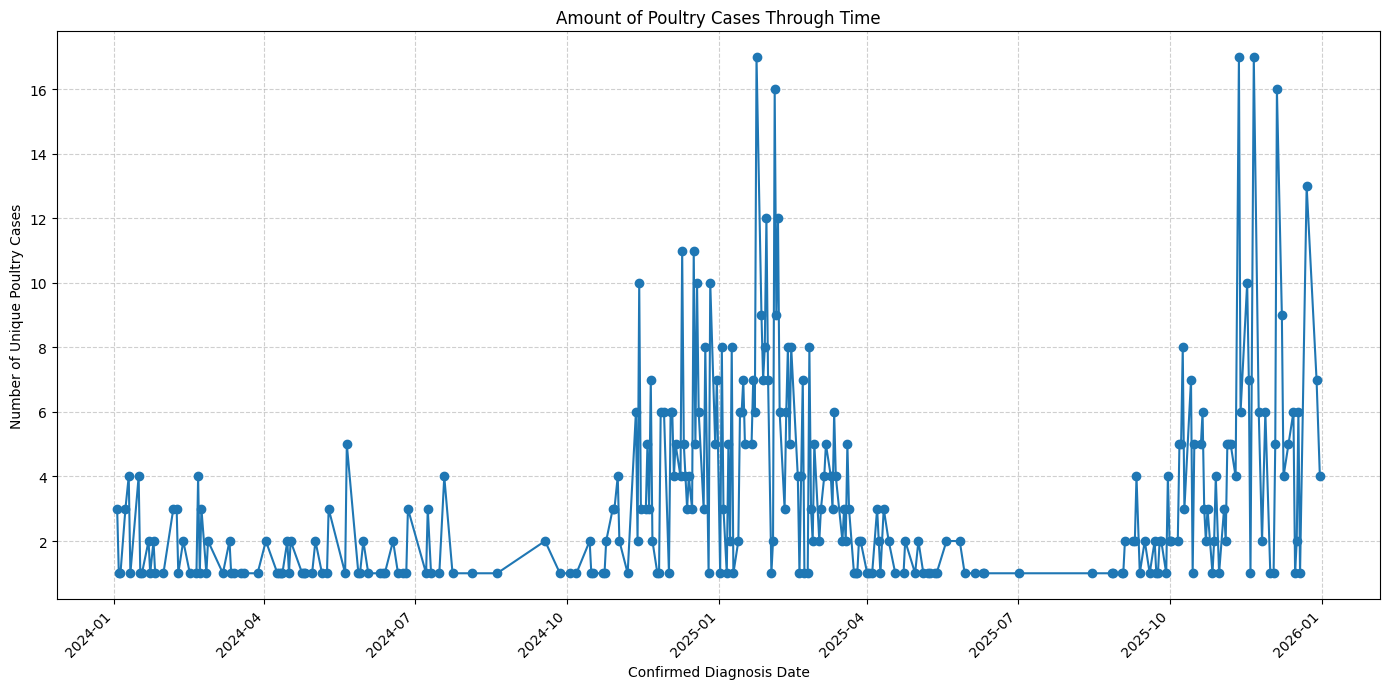

In [149]:
import matplotlib.pyplot as plt

# Group by 'Confirmed Diagnosis' and count unique 'Special ID's
poultry_counts_by_date = poultry_df.groupby('Confirmed Diagnosis')['Special ID'].nunique()

# Plotting the data
plt.figure(figsize=(14, 7))
poultry_counts_by_date.plot(kind='line', marker='o', linestyle='-')
plt.title('Amount of Poultry Cases Through Time')
plt.xlabel('Confirmed Diagnosis Date')
plt.ylabel('Number of Unique Poultry Cases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

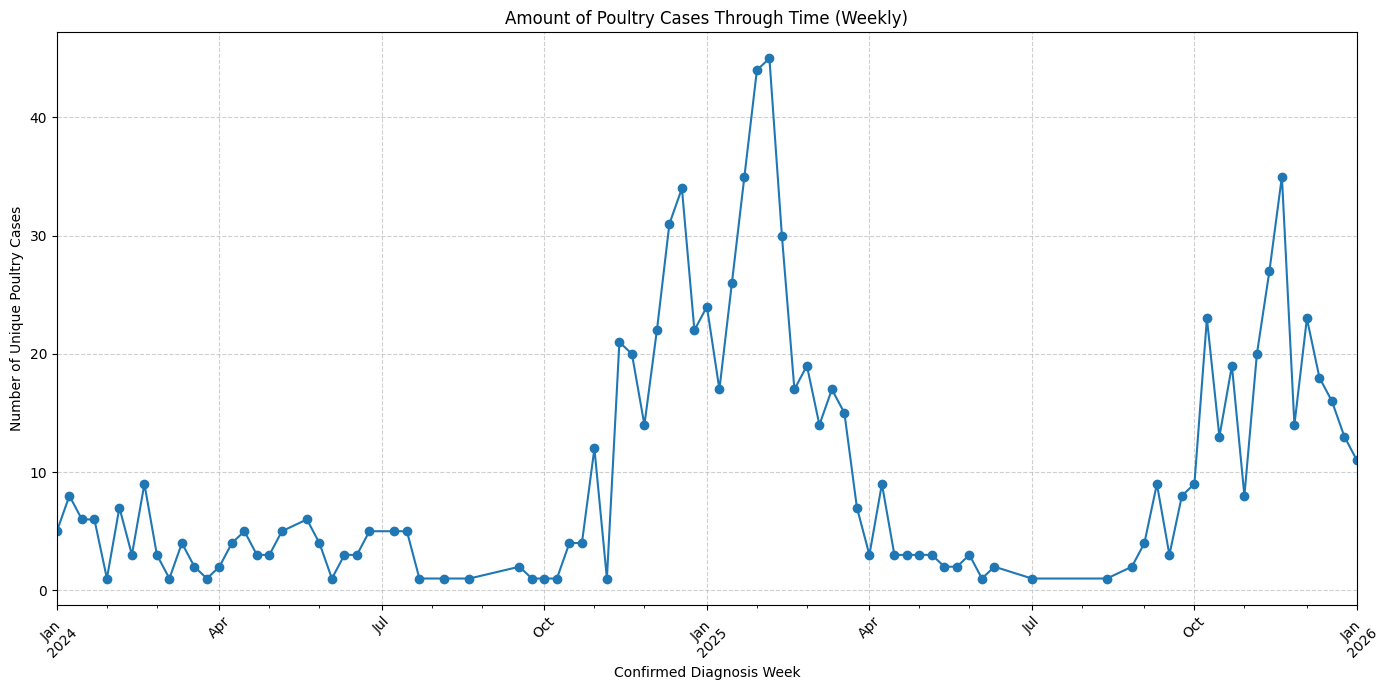

In [150]:
import matplotlib.pyplot as plt

# Ensure 'Confirmed Diagnosis' is a datetime object
poultry_df['Confirmed Diagnosis'] = pd.to_datetime(poultry_df['Confirmed Diagnosis'], errors='coerce')

# Group by week and count unique 'Special ID's
poultry_counts_by_week = poultry_df.groupby(poultry_df['Confirmed Diagnosis'].dt.to_period('W'))['Special ID'].nunique()

# Plotting the data
plt.figure(figsize=(14, 7))
poultry_counts_by_week.plot(kind='line', marker='o', linestyle='-')
plt.title('Amount of Poultry Cases Through Time (Weekly)')
plt.xlabel('Confirmed Diagnosis Week')
plt.ylabel('Number of Unique Poultry Cases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

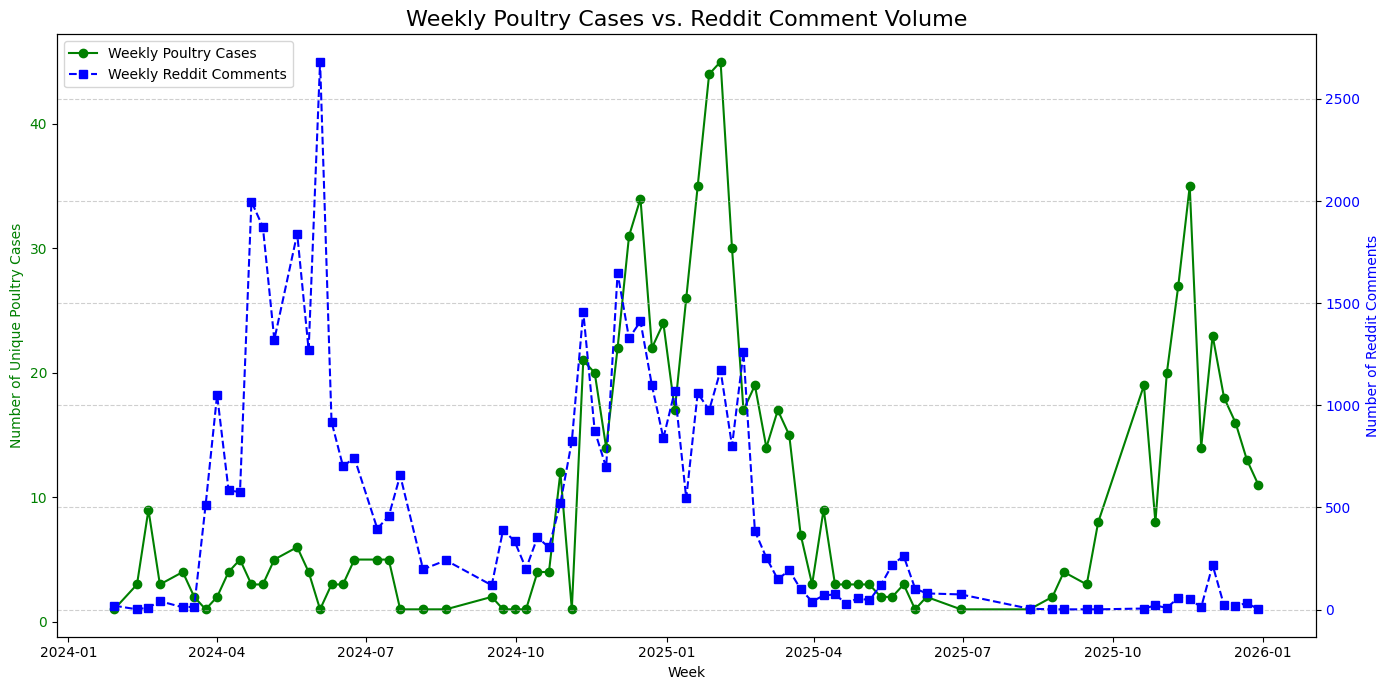

In [151]:
poultry_df['Confirmed Diagnosis'] = pd.to_datetime(poultry_df['Confirmed Diagnosis'], errors='coerce')
poultry_weekly = (
    poultry_df.groupby(poultry_df['Confirmed Diagnosis'].dt.to_period('W'))['Special ID']
    .nunique()
    .to_frame('poultry_cases')
)
poultry_weekly.index = poultry_weekly.index.to_timestamp() # Convert PeriodIndex to Timestamp for joining

combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')
reddit_weekly = (
    combined.groupby(combined['comment_created_utc'].dt.to_period('W'))
    .size()
    .to_frame('comment_count')
)
reddit_weekly.index = reddit_weekly.index.to_timestamp() # Ensure Timestamp index for joining

merged_poultry_reddit = poultry_weekly.join(reddit_weekly, how='inner').dropna()

plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Plot poultry cases on the left y-axis
ax1.plot(
    merged_poultry_reddit.index,
    merged_poultry_reddit['poultry_cases'],
    marker='o',
    color='green',
    label='Weekly Poultry Cases'
)
ax1.set_xlabel('Week')
ax1.set_ylabel('Number of Unique Poultry Cases', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Create a second y-axis for Reddit comment count
ax2 = ax1.twinx()
ax2.plot(
    merged_poultry_reddit.index,
    merged_poultry_reddit['comment_count'],
    marker='s',
    linestyle='--',
    color='blue',
    label='Weekly Reddit Comments'
)
ax2.set_ylabel('Number of Reddit Comments', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Weekly Poultry Cases vs. Reddit Comment Volume', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Cattle Cases


In [152]:
cattle_df=pd.read_csv('cattle_cases.csv')
cattle_df

,Confirmed Diagnosis,State,Special ID,Production
0,2025-12-13,Wisconsin,WI 001,Dairy Milking Cows
1,2025-11-26,California,CA 778,Dairy Milking Cows
2,2025-10-10,Idaho,ID 112,Dairy Milking Cows
3,2025-09-15,Nebraska,NE 001,Dairy Milking Cows
4,2025-09-02,Texas,TX 030,Dairy Milking Cows
...,...,...,...,...
1085,2024-03-27,Texas,TX 007,Dairy Milking Cows
1086,2024-03-26,Kansas,KS 001,Dairy Milking Cows
1087,2024-03-26,Kansas,KS 002,Dairy Milking Cows
1088,2024-03-26,Texas,TX 004,Dairy Milking Cows


In [153]:
cattle_df.shape

(1090, 4)

In [154]:
cattle_df.isna().sum()

,0
Confirmed Diagnosis,0
State,0
Special ID,0
Production,0


In [155]:
cattle_df.dtypes

,0
Confirmed Diagnosis,object
State,object
Special ID,object
Production,object


In [156]:
cattle_df['Confirmed Diagnosis'] = pd.to_datetime(cattle_df['Confirmed Diagnosis'], errors='coerce')
cattle_df.dtypes

,0
Confirmed Diagnosis,datetime64[ns]
State,object
Special ID,object
Production,object


In [157]:
print(f"Date range of cattle_df: {cattle_df['Confirmed Diagnosis'].min()} to {cattle_df['Confirmed Diagnosis'].max()}")

Date range of cattle_df: 2024-03-25 00:00:00 to 2025-12-13 00:00:00


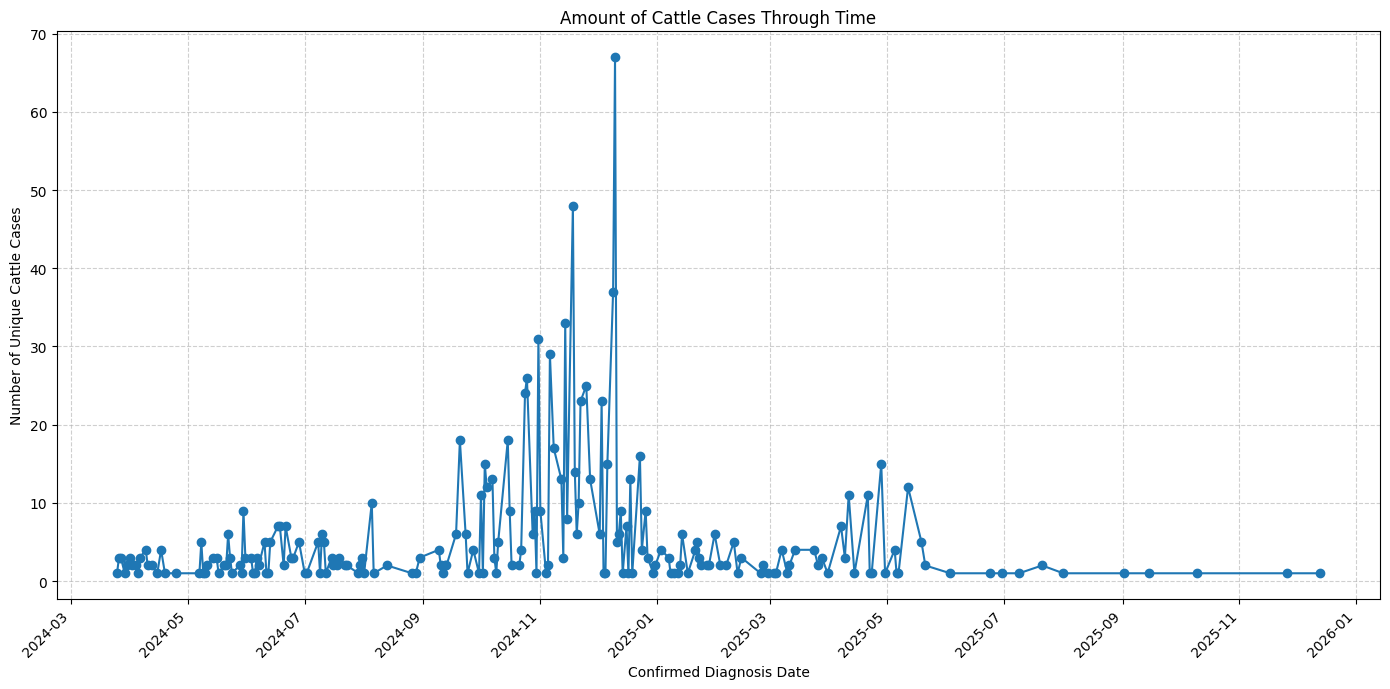

In [158]:
import matplotlib.pyplot as plt

# Group by 'Confirmed Diagnosis' and count unique 'Special ID's
cattle_counts_by_date = cattle_df.groupby('Confirmed Diagnosis')['Special ID'].nunique()

# Plotting the data
plt.figure(figsize=(14, 7))
cattle_counts_by_date.plot(kind='line', marker='o', linestyle='-')
plt.title('Amount of Cattle Cases Through Time')
plt.xlabel('Confirmed Diagnosis Date')
plt.ylabel('Number of Unique Cattle Cases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

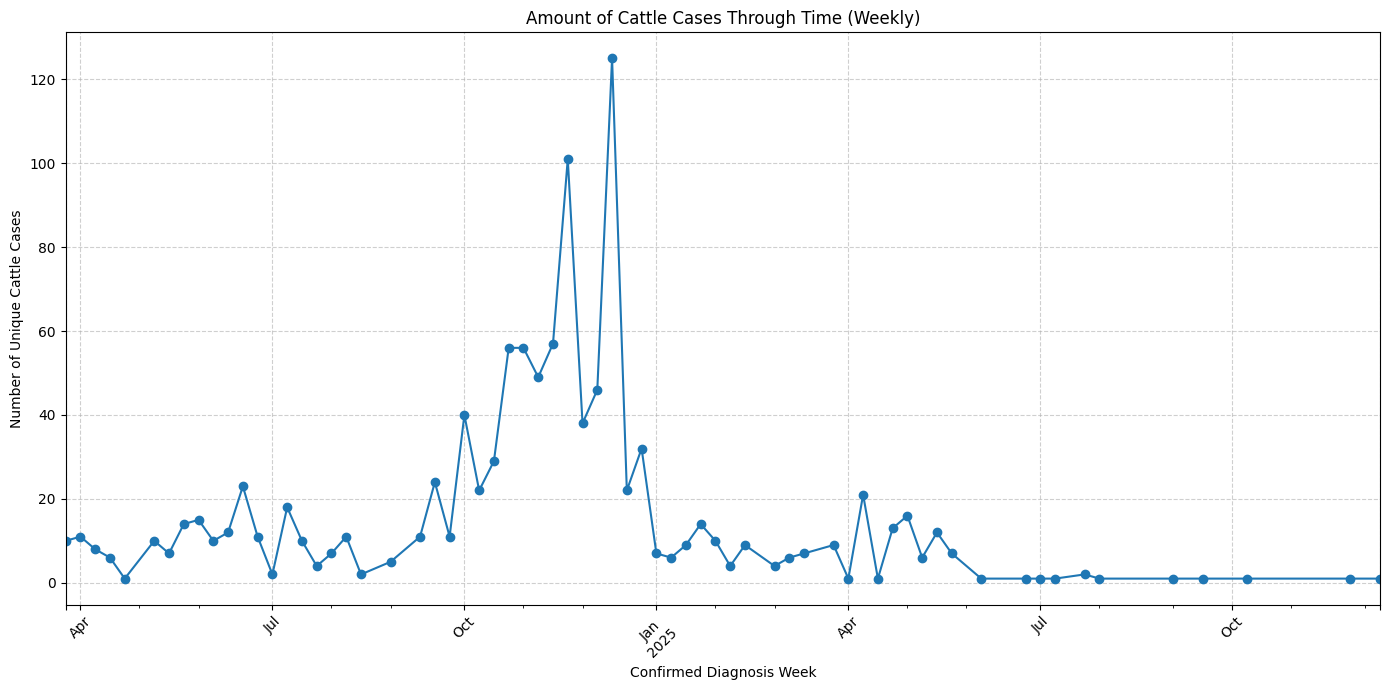

In [159]:
import matplotlib.pyplot as plt

# Ensure 'Confirmed Diagnosis' is a datetime object
cattle_df['Confirmed Diagnosis'] = pd.to_datetime(cattle_df['Confirmed Diagnosis'], errors='coerce')

# Group by week and count unique 'Special ID's
cattle_counts_by_week = cattle_df.groupby(cattle_df['Confirmed Diagnosis'].dt.to_period('W'))['Special ID'].nunique()

# Plotting the data
plt.figure(figsize=(14, 7))
cattle_counts_by_week.plot(kind='line', marker='o', linestyle='-')
plt.title('Amount of Cattle Cases Through Time (Weekly)')
plt.xlabel('Confirmed Diagnosis Week')
plt.ylabel('Number of Unique Cattle Cases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

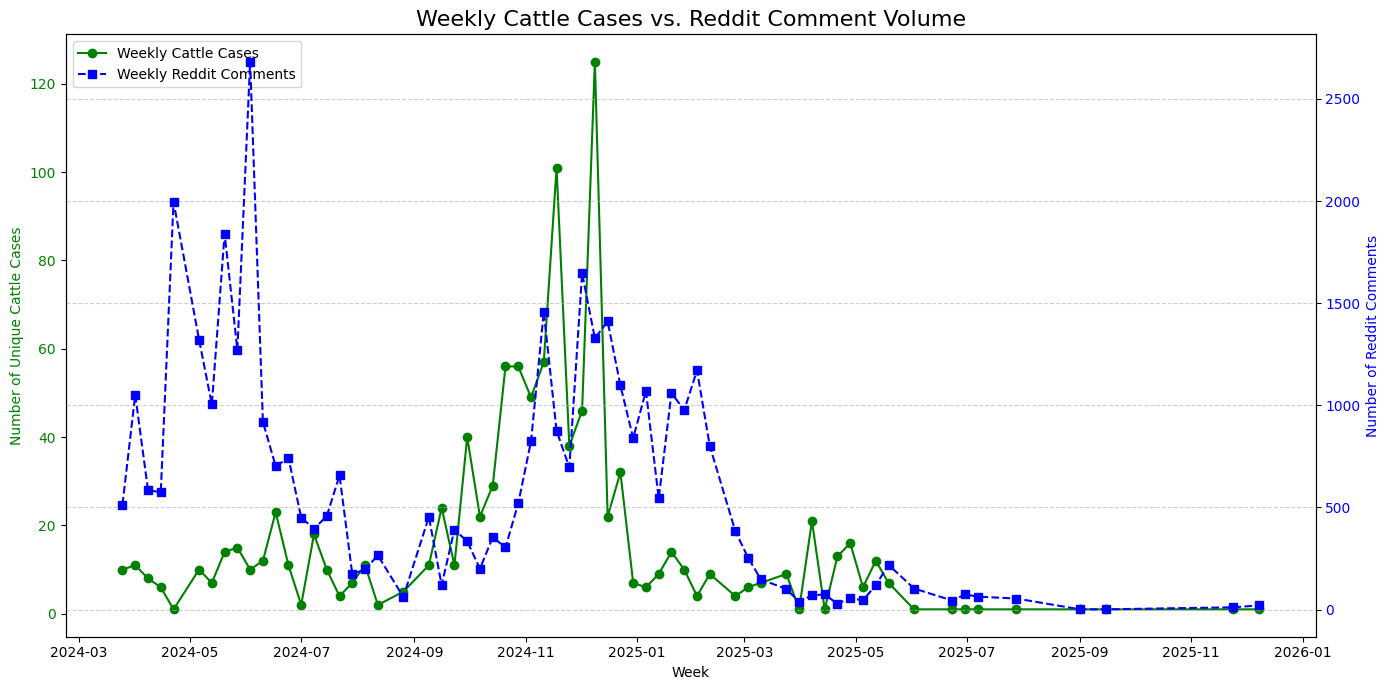

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'cattle_counts_by_week' index is converted to Timestamp for merging
cattle_weekly = cattle_counts_by_week.to_frame('cattle_cases')
cattle_weekly.index = cattle_weekly.index.to_timestamp()

# Ensure 'comment_created_utc' in combined is a datetime object
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')

# Group Reddit comments by week and count them
reddit_weekly = (
    combined.groupby(combined['comment_created_utc'].dt.to_period('W'))
    .size()
    .to_frame('comment_count')
)
# Convert PeriodIndex to Timestamp for joining
reddit_weekly.index = reddit_weekly.index.to_timestamp()

# Merge the two dataframes on their datetime index (inner join keeps only common weeks)
merged_cattle_reddit = cattle_weekly.join(reddit_weekly, how='inner').dropna()

# Plotting the data
plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Plot cattle cases on the left y-axis
ax1.plot(
    merged_cattle_reddit.index,
    merged_cattle_reddit['cattle_cases'],
    marker='o',
    color='green',
    label='Weekly Cattle Cases'
)
ax1.set_xlabel('Week')
ax1.set_ylabel('Number of Unique Cattle Cases', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Create a second y-axis for Reddit comment count
ax2 = ax1.twinx()
ax2.plot(
    merged_cattle_reddit.index,
    merged_cattle_reddit['comment_count'],
    marker='s',
    linestyle='--',
    color='blue',
    label='Weekly Reddit Comments'
)
ax2.set_ylabel('Number of Reddit Comments', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Weekly Cattle Cases vs. Reddit Comment Volume', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Mammals Cases

In [161]:
mammals_df=pd.read_csv('HPAI Detections in Mammals.csv')
mammals_df

,State,County,Date Collected,Date Detected,HPAI Strain,Species
0,Alaska,Nome,4/8/2026,4/22/2026,EA H5N1,American mink
1,California,San Mateo,4/15/2026,4/22/2026,EA H5N1,Northern elephant seal
2,California,San Mateo,2/12/2026,4/15/2026,EA H5N1,Northern elephant seal
3,California,San Mateo,2/12/2026,4/15/2026,EA H5N1,Northern elephant seal
4,California,San Mateo,2/12/2026,4/15/2026,EA H5N1,Northern elephant seal
...,...,...,...,...,...,...
795,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
796,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA/AM H5N1,Red fox
797,Wisconsin,Dane,5/5/2022,5/6/2022,EA/AM H5N1,Red fox
798,Wisconsin,Rock,4/19/2022,5/5/2022,EA/AM H5N1,Red fox


In [162]:
mammals_df.shape

(800, 6)

In [163]:
mammals_df.isna().sum()

,0
State,0
County,0
Date Collected,0
Date Detected,0
HPAI Strain,0
Species,0


In [164]:
mammals_df['Species'].value_counts()

,count
Species,
Domestic cat,154
Red fox,124
House mouse,111
Striped skunk,61
Northern elephant seal,54
Skunk (unidentified),34
Raccoon,31
Mountain lion,31
Harbor seal,27


In [165]:
mammals_df['Species'] = mammals_df['Species'].str.replace('Skunk (unidentified)', 'Skunk', regex=False)
mammals_df['Species'].value_counts()

,count
Species,
Domestic cat,154
Red fox,124
House mouse,111
Striped skunk,61
Northern elephant seal,54
Skunk,34
Raccoon,31
Mountain lion,31
Harbor seal,27


In [166]:
mammals_df['Species'] = mammals_df['Species'].str.replace('Striped skunk', 'Skunk', regex=False)

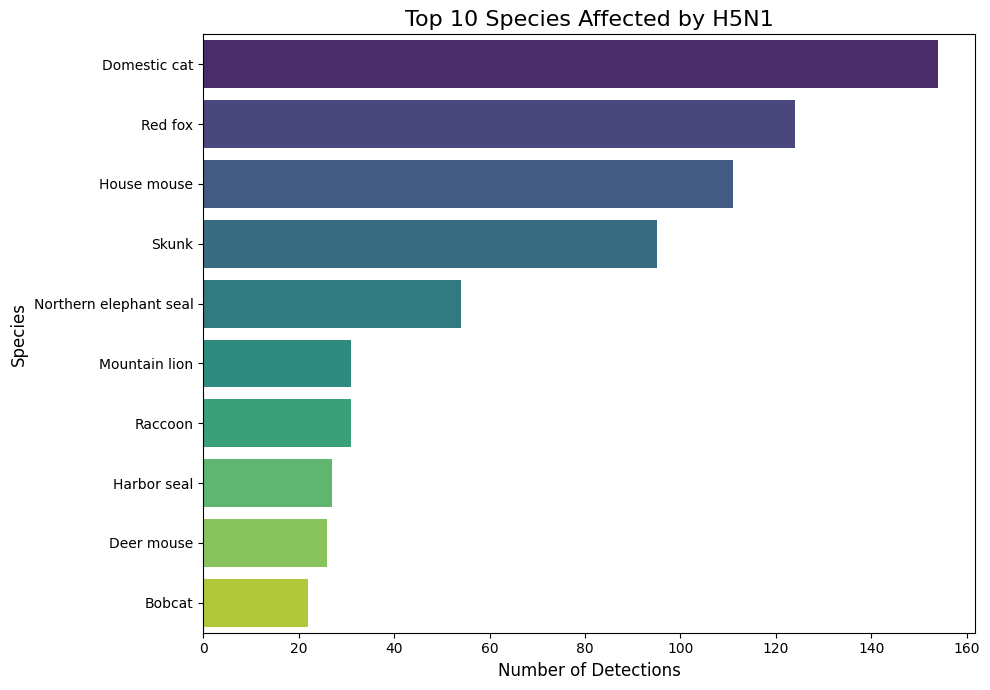

In [167]:
species_counts = mammals_df['Species'].value_counts().head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=species_counts.values, y=species_counts.index, hue=species_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Species Affected by H5N1', fontsize=16)
plt.xlabel('Number of Detections', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.tight_layout()
plt.show()

In [168]:
mammals_df['State'].nunique()

42

In [169]:
mammals_df['County'].nunique()

266

In [170]:
mammals_df['Date Collected'] = pd.to_datetime(mammals_df['Date Collected'], errors='coerce')
mammals_df['Date Detected'] = pd.to_datetime(mammals_df['Date Detected'], errors='coerce')

print(f"Date Collected range: {mammals_df['Date Collected'].min()} to {mammals_df['Date Collected'].max()}")
print(f"Date Detected range: {mammals_df['Date Detected'].min()} to {mammals_df['Date Detected'].max()}")

Date Collected range: 2022-03-30 00:00:00 to 2026-04-15 00:00:00
Date Detected range: 2022-05-05 00:00:00 to 2026-04-22 00:00:00


In [171]:
mammals_df['HPAI Strain'].value_counts()

,count
HPAI Strain,
EA/AM H5N1,425
EA H5N1,261
EA H5,114


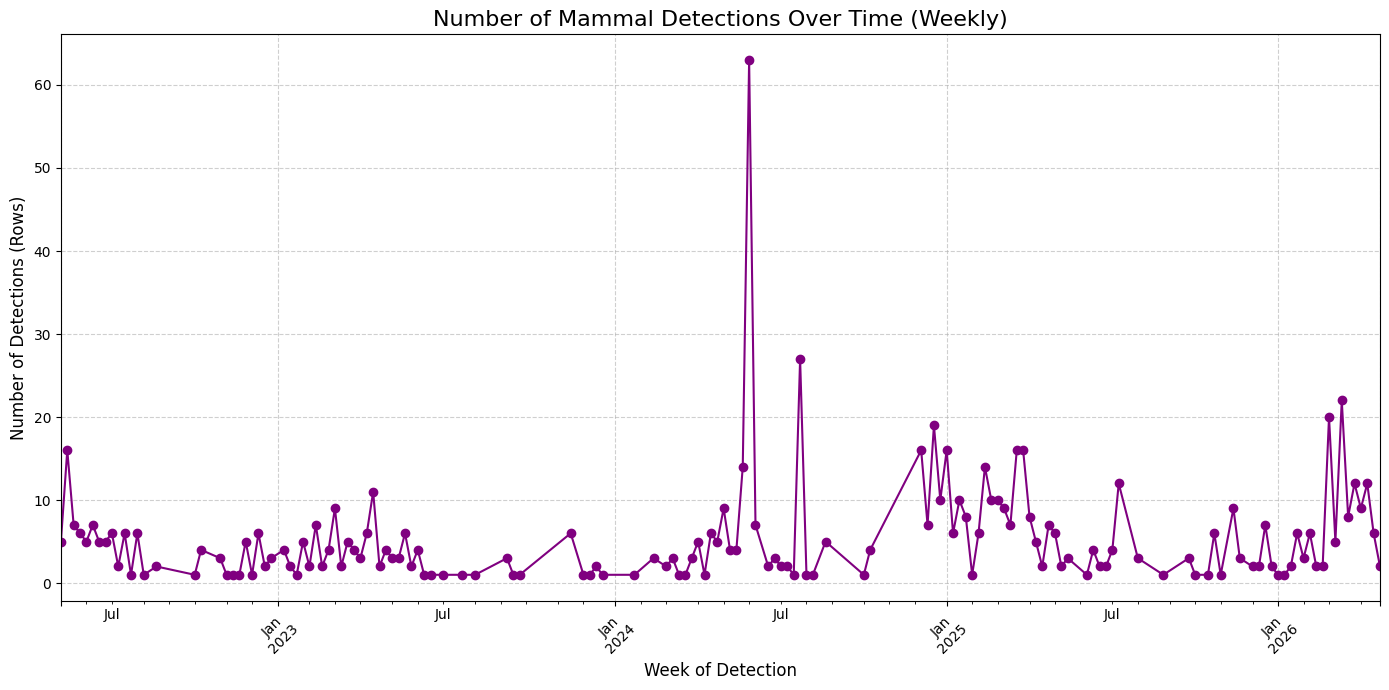

In [172]:
import matplotlib.pyplot as plt

# Ensure 'Date Detected' is a datetime object
mammals_df['Date Detected'] = pd.to_datetime(mammals_df['Date Detected'], errors='coerce')

# Group by week and count the number of detections
mammals_weekly_counts = mammals_df.groupby(mammals_df['Date Detected'].dt.to_period('W')).size()

# Plotting the data
plt.figure(figsize=(14, 7))
mammals_weekly_counts.plot(kind='line', marker='o', linestyle='-', color='purple')
plt.title('Number of Mammal Detections Over Time (Weekly)', fontsize=16)
plt.xlabel('Week of Detection', fontsize=12)
plt.ylabel('Number of Detections (Rows)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [173]:
filtered_mammals_df = mammals_df[
    (mammals_df['Date Detected'] >= '2024-01-01') &
    (mammals_df['Date Detected'] <= '2025-12-31')
].copy()

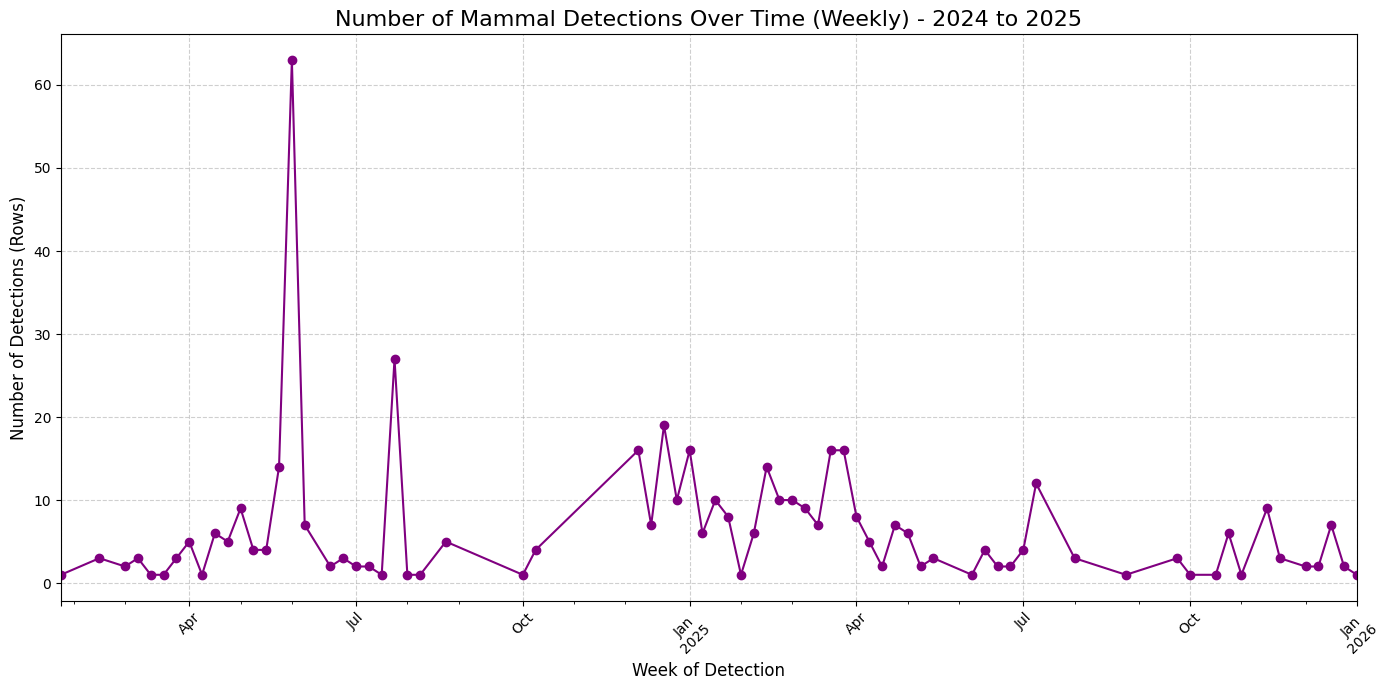

In [174]:
import matplotlib.pyplot as plt

# Ensure 'Date Detected' is a datetime object
filtered_mammals_df['Date Detected'] = pd.to_datetime(filtered_mammals_df['Date Detected'], errors='coerce')

# Group by week and count the number of detections
filtered_mammals_weekly_counts = filtered_mammals_df.groupby(filtered_mammals_df['Date Detected'].dt.to_period('W')).size()

# Plotting the data
plt.figure(figsize=(14, 7))
filtered_mammals_weekly_counts.plot(kind='line', marker='o', linestyle='-', color='purple')
plt.title('Number of Mammal Detections Over Time (Weekly) - 2024 to 2025', fontsize=16)
plt.xlabel('Week of Detection', fontsize=12)
plt.ylabel('Number of Detections (Rows)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [175]:
filtered_mammals_df.shape

(462, 6)

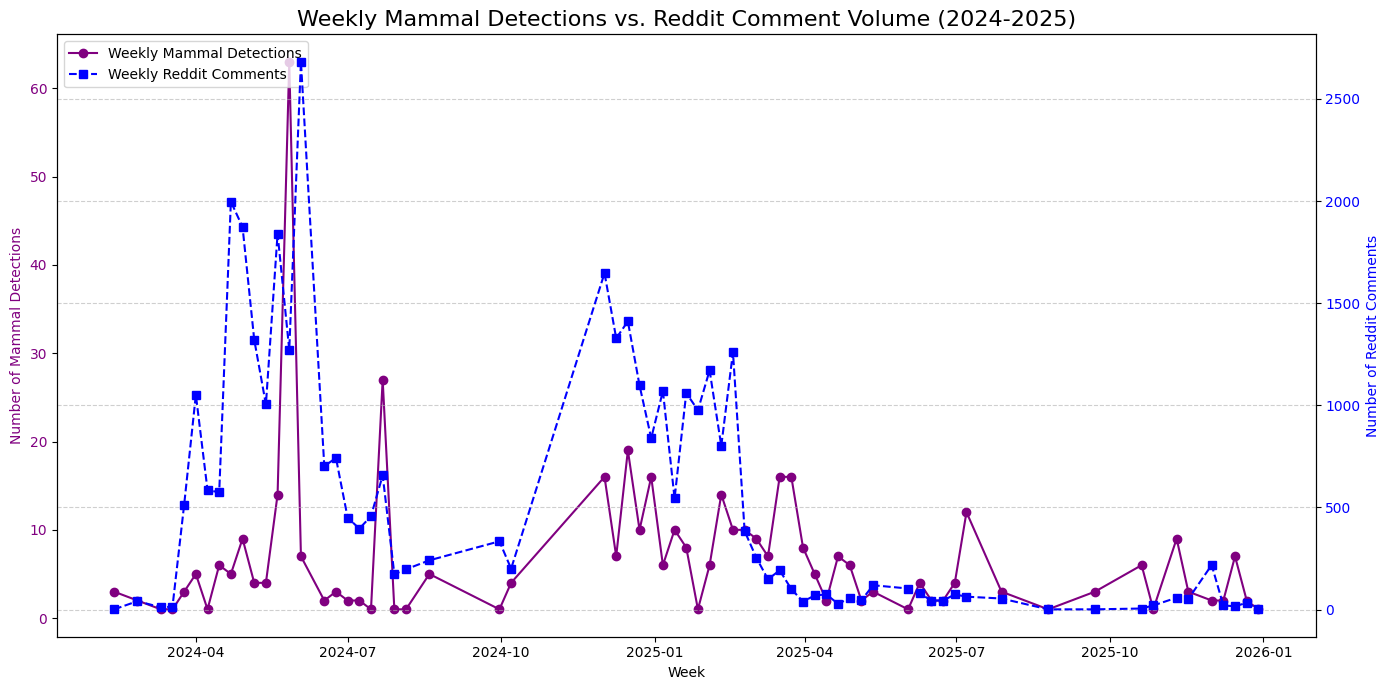

In [177]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure `filtered_mammals_weekly_counts` is a DataFrame with a Timestamp index
mammals_weekly_df = filtered_mammals_weekly_counts.to_frame('mammal_detections')
mammals_weekly_df.index = mammals_weekly_df.index.to_timestamp()

# Ensure `reddit_weekly` has a Timestamp index (it was likely created earlier as PeriodIndex)
# Re-create reddit_weekly to ensure it's up-to-date and has a Timestamp index
combined['comment_created_utc'] = pd.to_datetime(combined['comment_created_utc'], errors='coerce')
reddit_weekly = (
    combined.groupby(combined['comment_created_utc'].dt.to_period('W'))
    .size()
    .to_frame('comment_count')
)
reddit_weekly.index = reddit_weekly.index.to_timestamp()

# Merge the two dataframes on their datetime index (inner join keeps only common weeks)
merged_mammals_reddit = mammals_weekly_df.join(reddit_weekly, how='inner').dropna()

# Plotting the data
plt.figure(figsize=(14, 7))
ax1 = plt.gca()

# Plot mammal detections on the left y-axis
ax1.plot(
    merged_mammals_reddit.index,
    merged_mammals_reddit['mammal_detections'],
    marker='o',
    color='purple',
    label='Weekly Mammal Detections'
)
ax1.set_xlabel('Week')
ax1.set_ylabel('Number of Mammal Detections', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')

# Create a second y-axis for Reddit comment count
ax2 = ax1.twinx()
ax2.plot(
    merged_mammals_reddit.index,
    merged_mammals_reddit['comment_count'],
    marker='s',
    linestyle='--',  # Use a dashed line for clarity
    color='blue',
    label='Weekly Reddit Comments'
)
ax2.set_ylabel('Number of Reddit Comments', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Weekly Mammal Detections vs. Reddit Comment Volume (2024-2025)', fontsize=16)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Multiple Variables in One Graph

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all weekly dataframes have a datetime index and are within the desired range
# weekly_comments_filtered is already filtered from 2024-01-01
# poultry_weekly, cattle_weekly, mammals_weekly_df are already Timestamp indexed

# Filter poultry_weekly, cattle_weekly, and mammals_weekly_df to start from 2024-01-01
poultry_weekly_filtered = poultry_weekly[poultry_weekly.index >= '2024-01-01']
cattle_weekly_filtered = cattle_weekly[cattle_weekly.index >= '2024-01-01']
mammals_weekly_filtered = mammals_weekly_df[mammals_weekly_df.index >= '2024-01-01']

# Rename the index of weekly_comments_filtered for easier merging
weekly_comments_filtered_df = weekly_comments_filtered.to_frame('reddit_comments')
# Convert to DatetimeIndex BEFORE merging
weekly_comments_filtered_df.index = weekly_comments_filtered_df.index.to_timestamp()
weekly_comments_filtered_df.index.name = 'week'

# Merge all dataframes on their weekly index (outer join to get all weeks)
# All dataframes now have DatetimeIndex, so joins will be consistent.
merged_all_weekly = weekly_comments_filtered_df.join(poultry_weekly_filtered, how='outer')
merged_all_weekly = merged_all_weekly.join(cattle_weekly_filtered, how='outer')
merged_all_weekly = merged_all_weekly.join(mammals_weekly_filtered, how='outer')

# Fill NaN values with 0 for plotting purposes, as missing weeks mean 0 detections/comments
merged_all_weekly = merged_all_weekly.fillna(0)

plt.figure(figsize=(18, 9))

# Create the first y-axis for Reddit Comments
ax1 = plt.gca()

# Plot Reddit Comments on ax1 (left y-axis)
ax1.plot(
    merged_all_weekly.index,
    merged_all_weekly['reddit_comments'],
    marker='o',
    linestyle='-',
    color='blue',
    label='Weekly Reddit Comments'
)
ax1.set_ylabel('Weekly Reddit Comments', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Animal Cases
ax2 = ax1.twinx()

# Plot animal cases on ax2 (right y-axis)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['poultry_cases'],
    marker='x',
    linestyle='--',
    color='green',
    label='Weekly Poultry Cases'
)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['cattle_cases'],
    marker='s',
    linestyle='-.',
    color='red',
    label='Weekly Cattle Cases'
)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['mammal_detections'],
    marker='^',
    linestyle=':',
    color='purple',
    label='Weekly Mammal Detections'
)
ax2.set_ylabel('Animal Cases', color='black', fontsize=14)
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Weekly Trends of Reddit Comments, Poultry, Cattle, and Mammal Detections (2024-2025)', fontsize=18)
ax1.set_xlabel('Week', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all weekly dataframes have a datetime index and are within the desired range
# weekly_comments_filtered is already filtered from 2024-01-01
# poultry_weekly, cattle_weekly, mammals_weekly_df, and wild_weekly are already Timestamp indexed

# Filter poultry_weekly, cattle_weekly, mammals_weekly_df, and wild_weekly to start from 2024-01-01
poultry_weekly_filtered = poultry_weekly[poultry_weekly.index >= '2024-01-01']
cattle_weekly_filtered = cattle_weekly[cattle_weekly.index >= '2024-01-01']
mammals_weekly_filtered = mammals_weekly_df[mammals_weekly_df.index >= '2024-01-01']
wild_weekly_filtered = wild_weekly[wild_weekly.index >= '2024-01-01']

# Rename the index of weekly_comments_filtered for easier merging
weekly_comments_filtered_df = weekly_comments_filtered.to_frame('reddit_comments')
# Convert to DatetimeIndex BEFORE merging
weekly_comments_filtered_df.index = weekly_comments_filtered_df.index.to_timestamp()
weekly_comments_filtered_df.index.name = 'week'

# Merge all dataframes on their weekly index (outer join to get all weeks)
# All dataframes now have DatetimeIndex, so joins will be consistent.
merged_all_weekly = weekly_comments_filtered_df.join(poultry_weekly_filtered, how='outer')
merged_all_weekly = merged_all_weekly.join(cattle_weekly_filtered, how='outer')
merged_all_weekly = merged_all_weekly.join(mammals_weekly_filtered, how='outer')
merged_all_weekly = merged_all_weekly.join(wild_weekly_filtered, how='outer')

# Fill NaN values with 0 for plotting purposes, as missing weeks mean 0 detections/comments
merged_all_weekly = merged_all_weekly.fillna(0)

# Filter data to end on 2025-12-31
merged_all_weekly = merged_all_weekly[merged_all_weekly.index <= '2025-12-31']

plt.figure(figsize=(18, 9))

# Create the first y-axis for Reddit Comments
ax1 = plt.gca()

# Plot Reddit Comments on ax1 (left y-axis)
ax1.plot(
    merged_all_weekly.index,
    merged_all_weekly['reddit_comments'],
    marker='o',
    linestyle='-',
    color='blue',
    label='Weekly Reddit Comments'
)
ax1.set_ylabel('Weekly Reddit Comments', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Animal Cases
ax2 = ax1.twinx()

# Plot animal cases on ax2 (right y-axis)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['poultry_cases'],
    marker='x',
    linestyle='--',
    color='green',
    label='Weekly Poultry Cases'
)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['cattle_cases'],
    marker='s',
    linestyle='-.',
    color='red',
    label='Weekly Cattle Cases'
)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['mammal_detections'],
    marker='^',
    linestyle=':',
    color='purple',
    label='Weekly Mammal Detections'
)
ax2.plot(
    merged_all_weekly.index,
    merged_all_weekly['wild_detections'],
    marker='D',
    linestyle='--',
    color='darkgreen',
    label='Weekly Wild Bird Detections'
)
ax2.set_ylabel('Animal Cases (including Wild Birds)', color='black', fontsize=14)
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Weekly Trends of Reddit Comments, Poultry, Cattle, Mammal, and Wild Bird Detections (2024-2025)', fontsize=18)
ax1.set_xlabel('Week', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all weekly dataframes have a datetime index and are within the desired range
# These monthly dataframes were prepared in the previous cell (RQFH7YuJneK1)
# monthly_reddit_comments
# monthly_egg_prices
# news_monthly

# --- 1. Merge the selected monthly dataframes ---
merged_monthly_subset = monthly_reddit_comments.join(monthly_egg_prices, how='outer')
merged_monthly_subset = merged_monthly_subset.join(news_monthly, how='outer')

# Fill NaN values with 0 for plotting purposes, as missing months mean 0 detections/comments/price data
merged_monthly_subset = merged_monthly_subset.fillna(0)

# --- 2. Create the three Y-axis plot ---

plt.figure(figsize=(16, 8))

# Create the first y-axis for Reddit Comments
ax1 = plt.gca()

# Plot Reddit Comments on ax1 (left y-axis)
ax1.plot(
    merged_monthly_subset.index,
    merged_monthly_subset['reddit_comments'],
    marker='o',
    linestyle='-',
    color='blue',
    label='Monthly Reddit Comments'
)
ax1.set_ylabel('Monthly Reddit Comments', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for Google News Articles
ax2 = ax1.twinx()

# Adjust ax2's position to make space for ax3
ax2.spines['right'].set_position(('outward', 60))

# Plot Google News Articles on ax2
ax2.plot(
    merged_monthly_subset.index,
    merged_monthly_subset['article_count'],
    marker='^',
    linestyle=':',
    color='red',
    label='Google News Articles'
)

ax2.set_ylabel('Google News Articles Count', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')

# Create a third y-axis for Egg Prices
ax3 = ax1.twinx()

# Plot Egg Prices on ax3
ax3.plot(
    merged_monthly_subset.index,
    merged_monthly_subset['Eggs, Grade A large retail price'],
    marker='x',
    linestyle='--',
    color='green',
    label='Egg Prices (Retail)'
)
ax3.set_ylabel('Egg Prices (Retail) (USD)', color='green', fontsize=14)
ax3.tick_params(axis='y', labelcolor='green')

plt.title('Monthly Trends: Reddit Comments, Egg Prices, and News Articles (2024-2025)', fontsize=18)
ax1.set_xlabel('Month', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right')

# Combine legends from all three axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()